[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part4-customer-analytics/sec4.2_clv_pymc_marketing.ipynb)

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://github.com/takechanman1228/marketing-science-in-python"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# Customer Lifetime Value Prediction Demo

This script demonstrates the process of predicting Customer Lifetime Value (CLV) using the PyMC Marketing library.

The example is based on the [PyMC Marketing Quickstart](https://www.pymc-marketing.io/en/stable/notebooks/clv/clv_quickstart.html) and utilizes the **Dunnhumby "The Complete Journey"** dataset — the same grocery retail data used in the segmentation chapter (sec 4.1). This allows readers to follow the same 2,500 households from segmentation through CLV modeling.

## Installing and Importing Necessary Libraries

In [1]:
# Installing the PyMC Marketing library (uncomment when running in Colab/fresh env)
%pip install -q pymc_marketing==1.0.0 arviz arviz-plots xarray

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing required libraries
import os
os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,mode=FAST_COMPILE")

import warnings
# Keep reader output clean: arviz/pandas emit library warnings whose text
# includes absolute site-packages paths, which we do not want in committed
# outputs. (Convergence is reported explicitly via fit_summary / divergences.)
warnings.filterwarnings("ignore")

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arviz_base.labels import MapLabeller

from pymc_marketing import clv

In [3]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo root marker, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401

In [4]:
# `_retail_data` is a loose module under notebooks/, not part of the msbook
# package. Add notebooks/ to the path: ".." for a local checkout, and the
# cloned repo's notebooks/ on Colab (a missing path is silently ignored).
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "marketing-science-in-python/notebooks")
from _retail_data import load_dunnhumby_transactions, load_dunnhumby_demographics

SEED = 42

In [5]:
# Setting the style of the plots
azp.style.use("arviz-darkgrid")

%config InlineBackend.figure_format = "retina"

## Data Loading and Preprocessing

In [6]:
from datetime import datetime, timedelta

# Load Dunnhumby "The Complete Journey" transactions
# Same dataset used in the segmentation chapter (sec 4.1)
data_raw = load_dunnhumby_transactions()

# Convert DAY counter (1–711) to synthetic datetime for PyMC-Marketing
BASE_DATE = datetime(2012, 1, 1)
data_raw["InvoiceDate"] = data_raw["DAY"].apply(lambda d: BASE_DATE + timedelta(days=int(d) - 1))

print(f"Raw transactions: {data_raw.shape}")
data_raw.head()

Raw transactions: (2595732, 13)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,InvoiceDate
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,2012-01-01
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,2012-01-01
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,2012-01-01
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,2012-01-01
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,2012-01-01


In [7]:
# Dunnhumby data does not have explicit return/cancellation codes.
# Filter out negative SALES_VALUE rows (returns/adjustments) and zero-quantity rows.
data_raw = data_raw[
    (data_raw["SALES_VALUE"] > 0) &
    (data_raw["QUANTITY"] > 0)
].copy()
print(f"After filtering negative/zero values: {data_raw.shape}")

After filtering negative/zero values: (2576815, 13)


In [8]:
# Selecting relevant features and calculating total sales per line item
# In Dunnhumby, SALES_VALUE already represents the line-item revenue.
features = ['household_key', 'BASKET_ID', 'InvoiceDate', 'QUANTITY', 'SALES_VALUE']
data = data_raw[features].copy()

# Rename for consistency with downstream code
data = data.rename(columns={
    'household_key': 'CustomerID',
    'SALES_VALUE': 'TotalSales',
})
data['CustomerID'] = data['CustomerID'].astype(str)

print(data.shape)
data.head()

(2576815, 5)


,CustomerID,BASKET_ID,InvoiceDate,QUANTITY,TotalSales
0,2375,26984851472,2012-01-01,1,1.39
1,2375,26984851472,2012-01-01,1,0.82
2,2375,26984851472,2012-01-01,1,0.99
3,2375,26984851472,2012-01-01,1,1.21
4,2375,26984851472,2012-01-01,1,1.50


In [9]:
# Checking for missing values
pd.DataFrame(zip(data.isnull().sum(), data.isnull().sum()/len(data)), columns=['Count', 'Proportion'], index=data.columns)

,Count,Proportion
CustomerID,0,0.0
BASKET_ID,0,0.0
InvoiceDate,0,0.0
QUANTITY,0,0.0
TotalSales,0,0.0


## Exploratory Data Analysis

In [10]:
# Summarizing the dataset's content to understand its scope
maxdate = data['InvoiceDate'].dt.date.max()
mindate = data['InvoiceDate'].dt.date.min()
unique_cust = data['CustomerID'].nunique()
tot_quantity = data['QUANTITY'].sum()
tot_sales = data['TotalSales'].sum()

print(f"The time range of transactions is: {mindate} to {maxdate}")
print(f"Total number of unique customers (households): {unique_cust}")
print(f"Total Quantity Sold: {tot_quantity}")
print(f"Total Sales for the period: ${tot_sales:,.2f}")

The time range of transactions is: 2012-01-01 to 2013-12-11
Total number of unique customers (households): 2500
Total Quantity Sold: 260681078
Total Sales for the period: $8,057,443.80


## BG/NBD Model

The BG/NBD model is a probabilistic model that predicts the purchases customers will make in a given period based on their past behavior.

## RFM-T Format
We will use the BG/NBD model to infer the frequency of repeat purchases for all customers in the dataset.

* `frequency` represents the number of _repeat_ purchases that a customer has made, i.e. one less than the total number of purchases;
* `T` represents a customer's "age", i.e. the duration between a customer's first purchase and the end of the period of study. In this example notebook, the units of time are in **days**;
* `recency` represents the timepoint when a customer made their most recent purchase. This is also equal to the duration between a customer's first non-repeat purchase (usually time 0) and last purchase. If a customer has made only 1 purchase, their recency is 0;
* `monetary_value` represents the average value of a given customer's purchases. This is equal to the sum of all a customer's purchases divided by the total number of purchases.

In [11]:
# Here, we prepare a summary from transaction data, transforming individual transaction data into data at the customer level.

data_summary = clv.utils.rfm_summary(
    data,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="TotalSales",
    time_unit="D",
)
data_summary = data_summary.set_index("customer_id", drop=False)
data_summary.head()

,customer_id,frequency,recency,T,monetary_value
customer_id,,,,,
1,1,77.0,655.0,660.0,55.214286
10,10,4.0,571.0,597.0,44.947500
100,100,27.0,685.0,705.0,82.451852
1000,1000,126.0,657.0,662.0,32.721746
1001,1001,78.0,694.0,695.0,51.830256


In [12]:
# BG/NBD models *all* customers, including frequency=0 single-purchase ones,
# so we deliberately keep them in `data_summary`. The Gamma-Gamma fit later
# filters to `frequency > 0` and `monetary_value > 0` (the monetary-value model
# requires repeat purchases, and v1.0 rejects non-positive spend). Do not drop
# `monetary_value <= 0` rows here. That would silently shrink the BG/NBD
# training set.

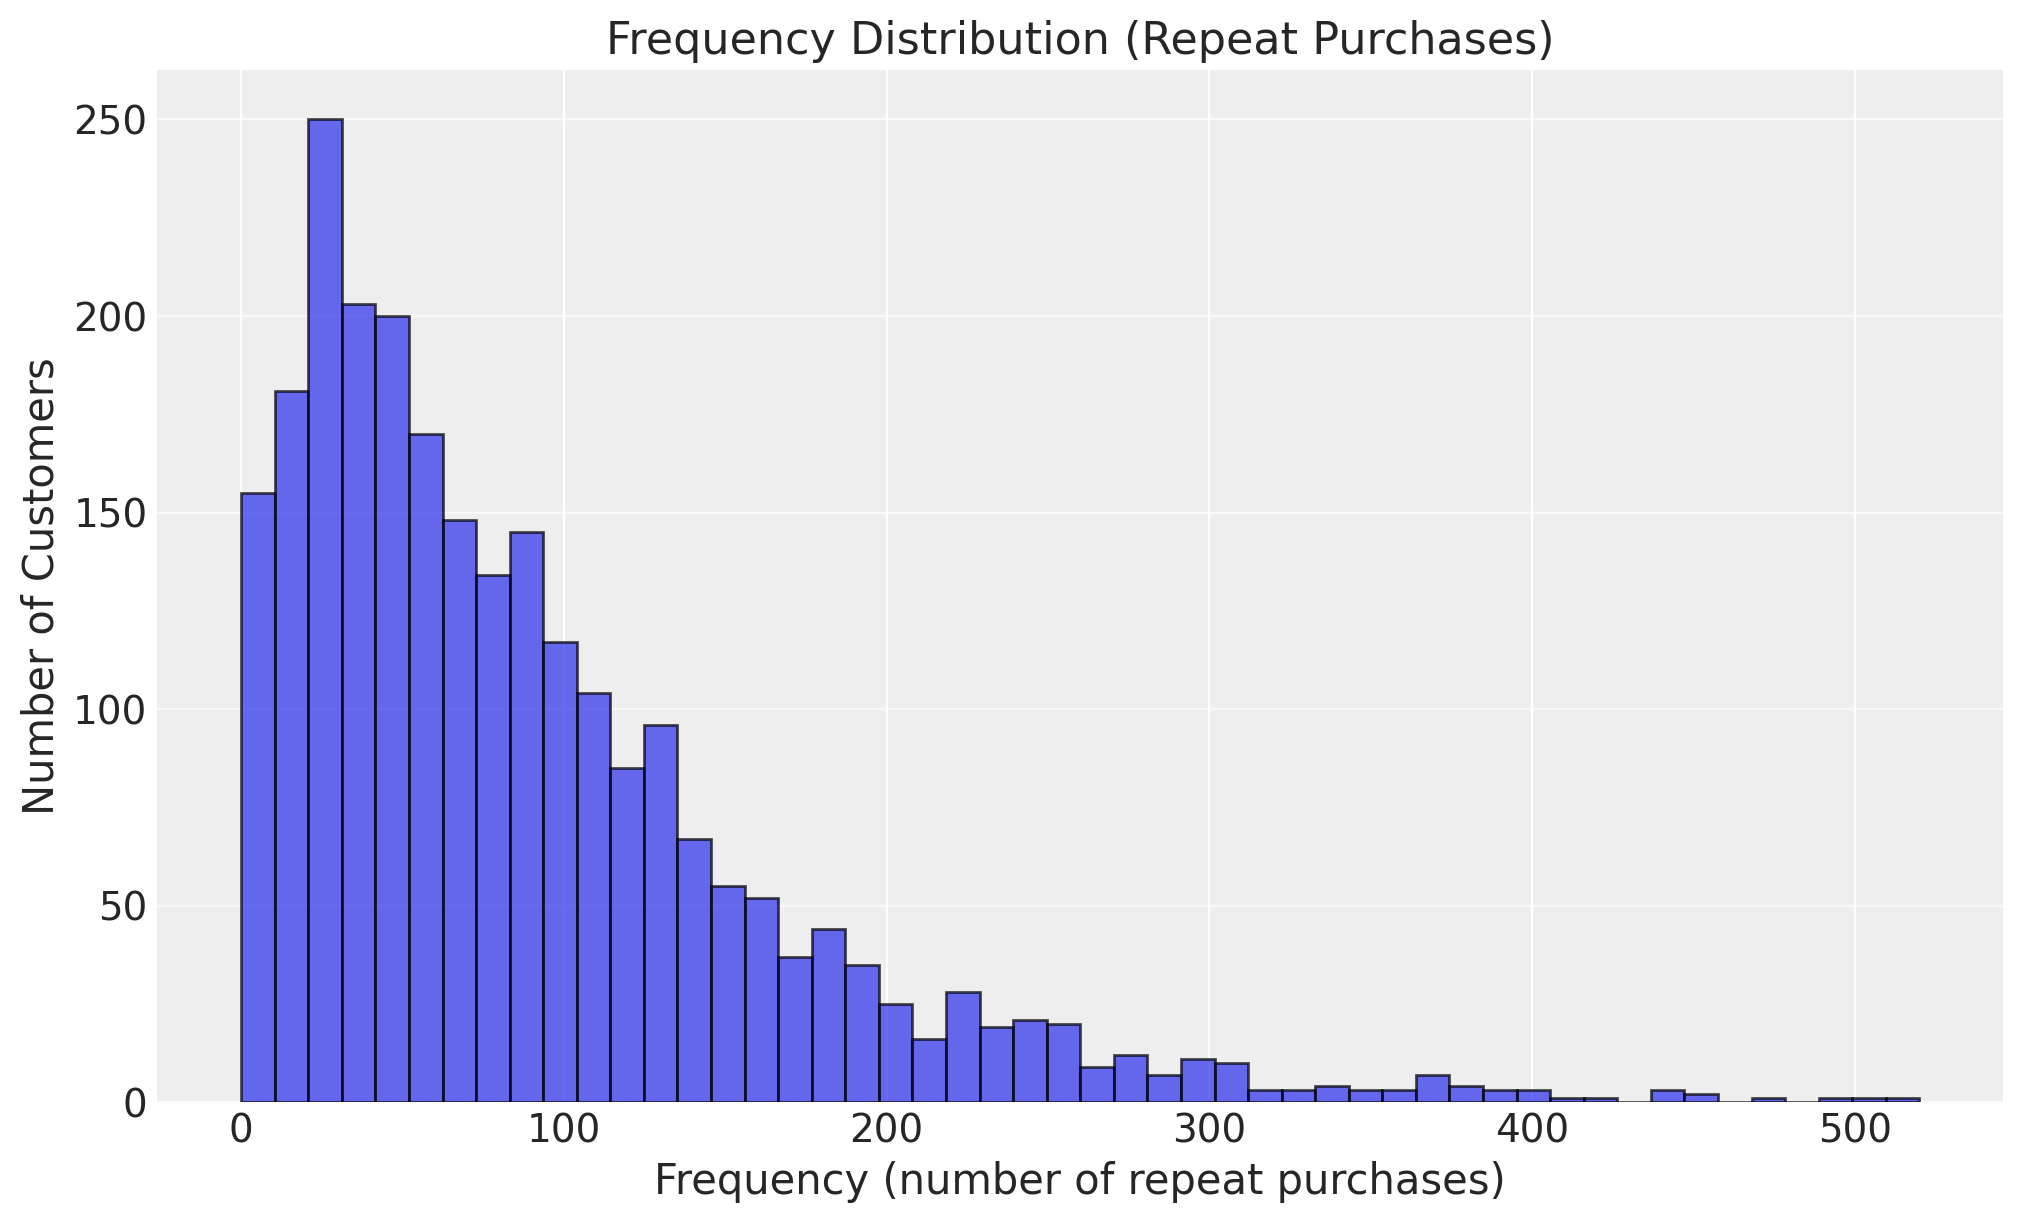

Frequency stats:
count    2500.000000
mean       89.113600
std        76.259702
min         0.000000
25%        33.000000
50%        69.000000
75%       123.000000
max       520.000000
Name: frequency, dtype: float64

Percentage of one-time-only customers (frequency=0): 0.12%


In [13]:
# Plotting the frequency distribution of customers
# Dunnhumby households are highly active: median frequency ~69 repeat purchases.
plt.figure(figsize=(10, 6))
plt.hist(data_summary['frequency'], bins=50, edgecolor='k', alpha=0.7)
plt.title('Frequency Distribution (Repeat Purchases)')
plt.xlabel('Frequency (number of repeat purchases)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.6)
plt.show()

print(f"Frequency stats:\n{data_summary['frequency'].describe()}")
zero_freq = round(sum(data_summary['frequency'] == 0) / float(len(data_summary)) * 100, 2)
print(f"\nPercentage of one-time-only customers (frequency=0): {zero_freq}%")

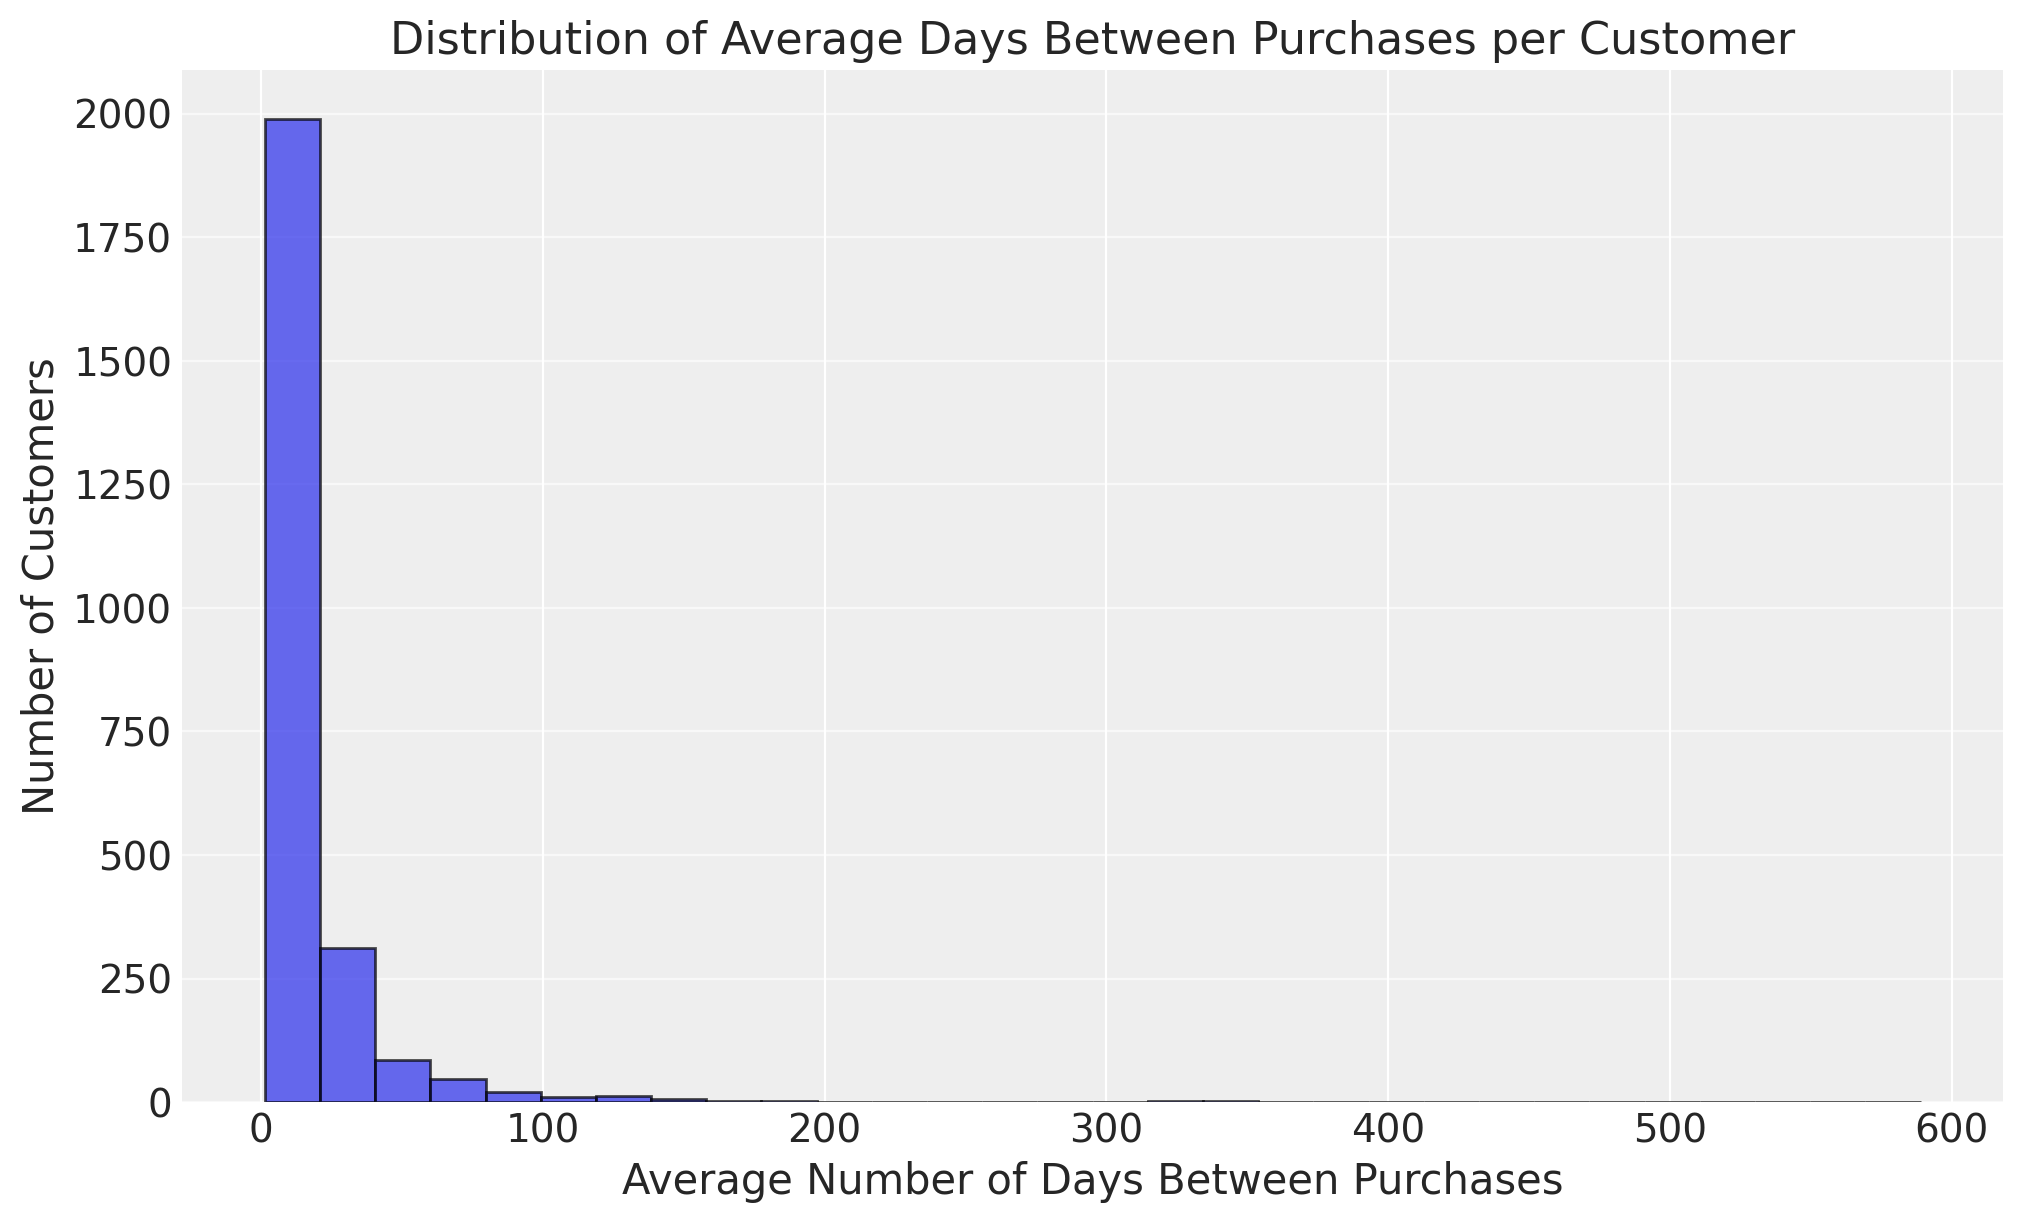

In [14]:
# Calculating Days Between Purchases

# Select distinct CustomerID and InvoiceDate
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
unique_purchases = data[['CustomerID', 'InvoiceDate']].drop_duplicates()

# Sorting values to ensure the calculation of the difference correctly
unique_purchases = unique_purchases.sort_values(['CustomerID', 'InvoiceDate'])

# Calculating the difference in days between current and next purchase
unique_purchases['NextInvoiceDate'] = unique_purchases.groupby('CustomerID')['InvoiceDate'].shift(-1)
unique_purchases['DaysBetween'] = (unique_purchases['NextInvoiceDate'] - unique_purchases['InvoiceDate']).dt.days

# Calculating Average Days
customer_avg_days = unique_purchases.groupby('CustomerID')['DaysBetween'].mean().dropna()

# Plotting the Histogram
plt.figure(figsize=(10, 6))
plt.hist(customer_avg_days, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Average Days Between Purchases per Customer')
plt.xlabel('Average Number of Days Between Purchases')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.6)
plt.show()

In [15]:
data_summary

,customer_id,frequency,recency,T,monetary_value
customer_id,,,,,
1,1,77.0,655.0,660.0,55.214286
10,10,4.0,571.0,597.0,44.947500
100,100,27.0,685.0,705.0,82.451852
1000,1000,126.0,657.0,662.0,32.721746
1001,1001,78.0,694.0,695.0,51.830256
...,...,...,...,...,...
995,995,20.0,633.0,641.0,60.492500
996,996,125.0,697.0,697.0,17.678400
997,997,85.0,678.0,678.0,54.261412


In [16]:
# Initializing the BG/NBD model with default priors.
bgm = clv.BetaGeoModel()
bgm

BG/NBD

PyMC-Marketing 1.0 uses weakly informative defaults for BG/NBD:
`alpha ~ Weibull(2, 10)`, `r ~ Weibull(2, 1)`, and a dropout
reparameterization with `phi_dropout ~ Uniform(0, 1)` and
`kappa_dropout ~ Pareto(1, 1)`. The familiar `a` and `b` parameters are
derived deterministically from `phi_dropout` and `kappa_dropout`, so they
remain available in the posterior and in the equations below.

We use those defaults here. When domain knowledge justifies a different
prior, pass a `model_config` built with `pymc_extras.prior.Prior`, for example:

```python
from pymc_extras.prior import Prior
custom_config = {"alpha": Prior("Weibull", alpha=2, beta=10)}
custom_bgm = clv.BetaGeoModel(model_config=custom_config)
```

Having specified the model, we can now fit it.

In [17]:
# Fit via NUTS MCMC so we get a real posterior, not just a point estimate.
# Sampling 2,500 households with a 4-parameter BG/NBD can take tens of minutes
# on a laptop CPU. Tighter `target_accept` keeps divergences near zero on this
# zero-inflated frequency distribution; the resulting HDI bounds are what the
# chapter promises as "uncertainty quantification."
bgm.fit(
    data=data_summary,
    chains=4,
    draws=1000,
    tune=1000,
    target_accept=0.95,
    random_seed=SEED,
    progressbar=False,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, phi_dropout, kappa_dropout, r]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 577 seconds.


Output()

<xarray.DataTree>
Group: /
│   Attributes:
│       id:              06fdfbaf8d8047a7
│       model_type:      BG/NBD
│       version:         None
│       sampler_config:  {}
│       model_config:    {"alpha": {"dist": "Weibull", "kwargs": {"alpha": 2, "be...
├── Group: /posterior
│       Dimensions:        (chain: 4, draw: 1000)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           alpha          (chain, draw) float64 32kB 10.54 10.5 10.51 ... 10.07 10.23
│           phi_dropout    (chain, draw) float64 32kB 0.0005058 0.0005474 ... 0.0004702
│           kappa_dropout  (chain, draw) float64 32kB 989.2 398.1 ... 594.5 5.886e+03
│           r              (chain, draw) float64 32kB 1.478 1.506 1.433 ... 1.43 1.408
│           a              (chain, draw) float64 32kB 0.5003 0.218 ... 0.2657 2.767
│           b              (chain, draw) float64 32kB 988.7 397.9 ... 594.2 5.883e+03
│       Attributes:
│           created_at:                 2026-08-25T02:11:05.648133+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              577.0903370380402
│           tuning_steps:               1000
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           perf_counter_start     (chain, draw) float64 32kB 3.623e+05 ... 3.625e+05
│           lp                     (chain, draw) float64 32kB -5.978e+05 ... -5.978e+05
│           max_energy_error       (chain, draw) float64 32kB -0.06683 0.1946 ... 0.1458
│           step_size_bar          (chain, draw) float64 32kB 0.3107 0.3107 ... 0.2917
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           index_in_trajectory    (chain, draw) int64 32kB -3 2 7 4 -4 ... -6 6 7 -3 6
│           ...                     ...
│           energy                 (chain, draw) float64 32kB 5.978e+05 ... 5.978e+05
│           step_size              (chain, draw) float64 32kB 0.3458 0.3458 ... 0.2456
│           process_time_diff      (chain, draw) float64 32kB 0.1307 0.1302 ... 0.2618
│           acceptance_rate        (chain, draw) float64 32kB 0.9891 0.8983 ... 0.9314
│           perf_counter_diff      (chain, draw) float64 32kB 0.1384 0.1348 ... 0.2626
│           energy_error           (chain, draw) float64 32kB -0.06683 0.1666 ... 0.1148
│       Attributes:
│           created_at:                 2026-08-25T02:11:05.659425+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              577.0903370380402
│           tuning_steps:               1000
├── Group: /observed_data
│       Dimensions:            (customer_id: 2500, obs_var: 2)
│       Coordinates:
│         * customer_id        (customer_id) <U4 40kB '1' '10' '100' ... '998' '999'
│         * obs_var            (obs_var) <U9 72B 'recency' 'frequency'
│       Data variables:
│           recency_frequency  (customer_id, obs_var) float64 40kB 655.0 77.0 ... 45.0
│       Attributes:
│           created_at:                 2026-08-25T02:11:05.663008+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creati

In [18]:
# Convergence diagnostics: r_hat should be ≤ 1.01 and divergences ≈ 0 for the
# posterior to be trustworthy. `fit_summary` *returns* the per-parameter
# r_hat / ESS table (it does not print), so leave it as the cell's last
# expression for the notebook to render it.
n_divergent = int(bgm.idata.sample_stats["diverging"].sum().item())
print(f"BG/NBD divergences: {n_divergent}")
bgm.fit_summary()

BG/NBD divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,10.5,0.33,10,11,1794,1986,1.00,0.0079,0.0056
phi_dropout,0.0005,6.9e-05,0.0004,0.00062,2114,2128,1.00,1.5e-06,1.2e-06
kappa_dropout,2.97e+03,1.32e+04,220,8000,1662,1509,1.00,340,3900
r,1.464,0.039,1.4,1.5,1814,1910,1.00,0.00092,0.00065
a,1.4,6,0.13,3.6,1802,1629,1.00,0.15,1.6
b,2.97e+03,1.32e+04,220,8000,1662,1509,1.00,340,3900


We can use [ArviZ](https://python.arviz.org/en/stable/), a Python library tailored to produce visualizations for Bayesian models, to plot the posterior distribution of each parameter.

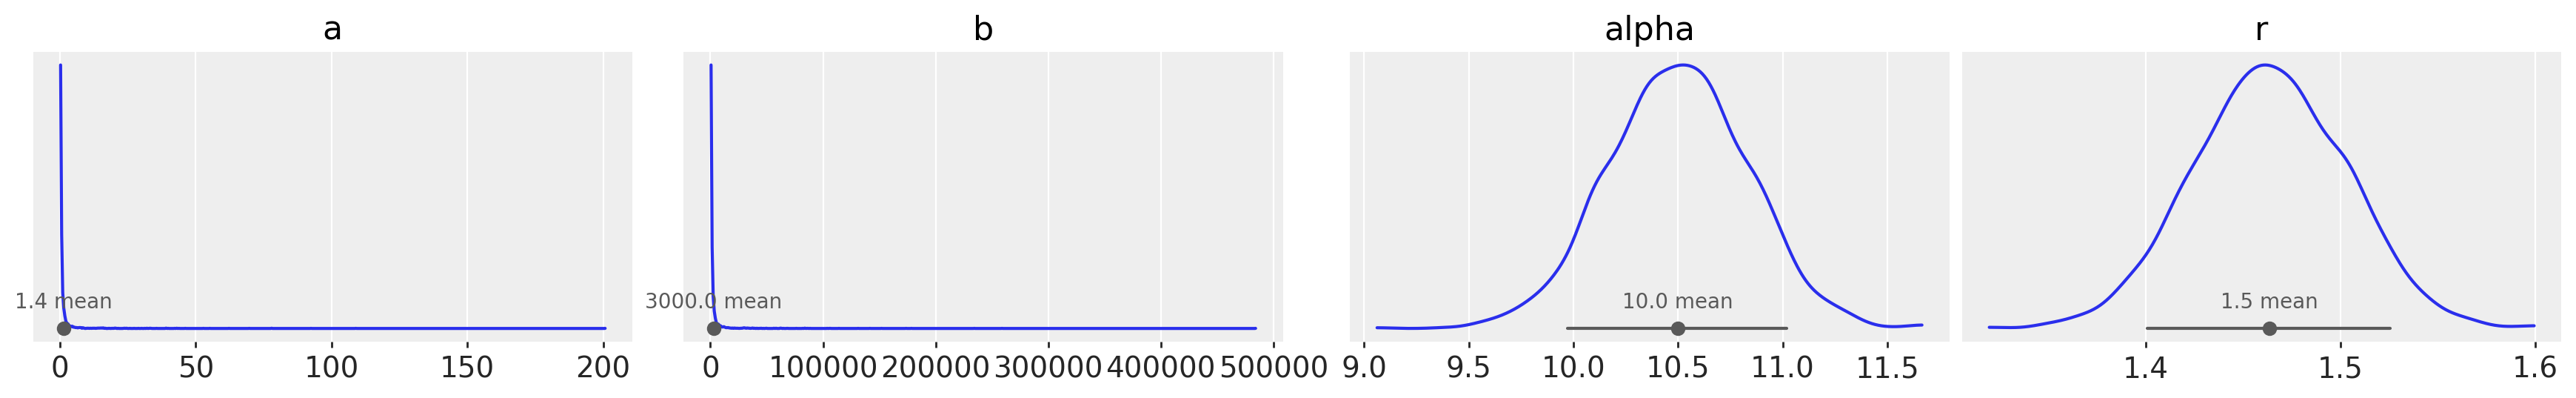

In [19]:
# Visualizing the posterior distributions of the parameters.
# Width of each density now reflects sampling uncertainty rather than collapsing
# to a single point (as it did under MAP).

azp.plot_dist(bgm.idata, var_names=["a", "b", "alpha", "r"]);

The spread of the distributions indicates the uncertainty in the estimates. Narrower distributions suggest more precise estimates.

### Visualizing the Frequency/Recency Matrix

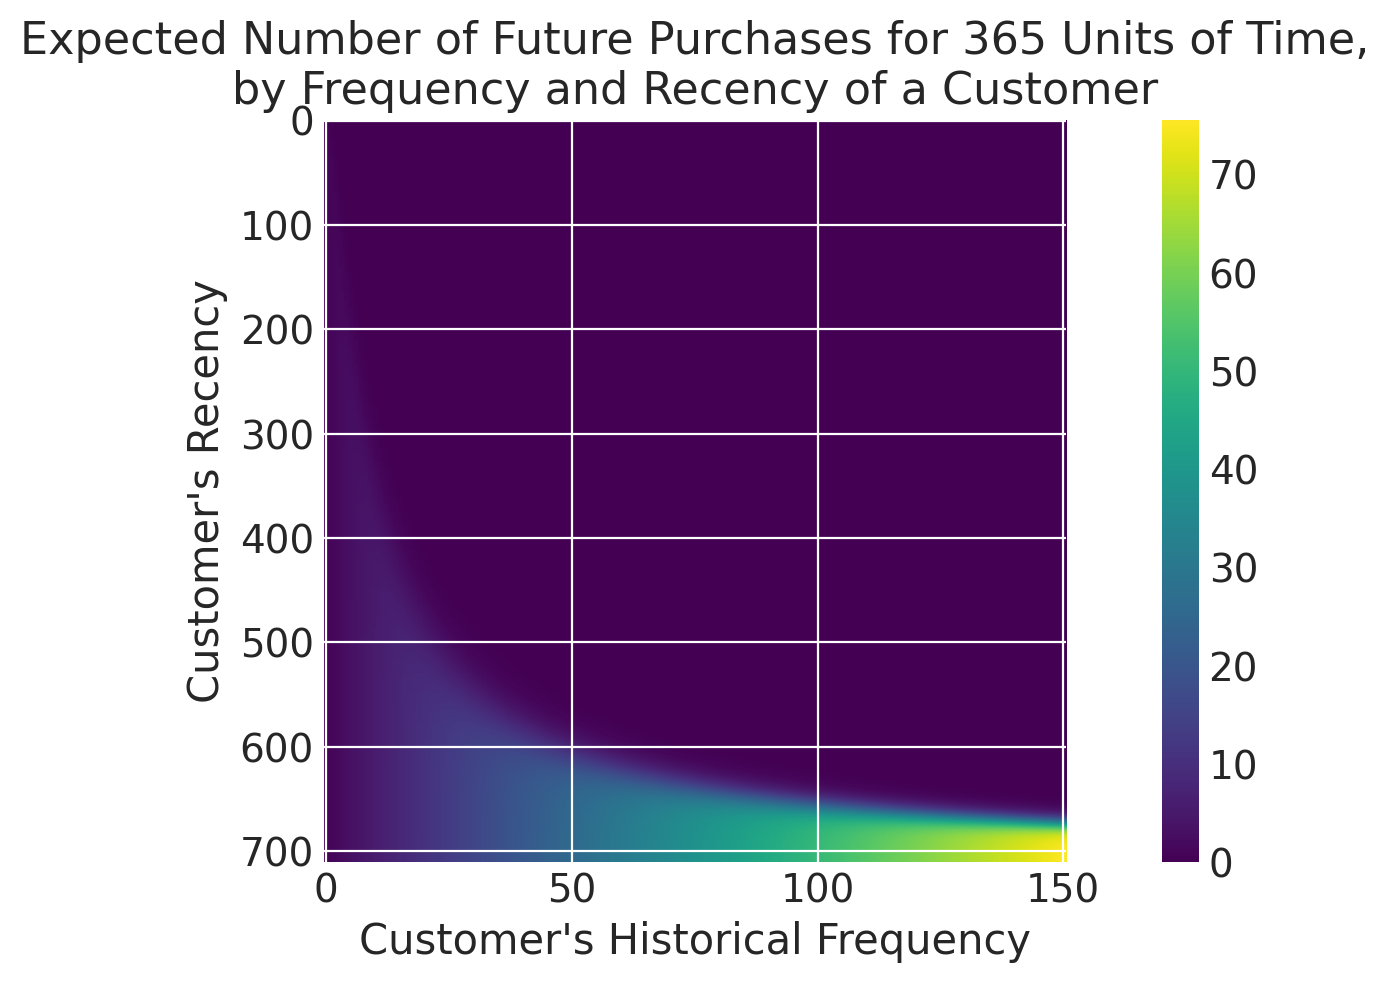

In [20]:
# Analyzing customer behavior using a Frequency/Recency matrix, which visualizes customer archetypes.
# This matrix helps in identifying patterns like potentially "at-risk" customers who might churn.
#
# Cap the frequency axis at 150: the raw max is ~520 (a 0.12% outlier; the 75th
# percentile is 123), so the uncapped matrix stretches to an empty corner and is
# harder to read. Capping also bounds the grid the model evaluates over the full
# posterior, which keeps memory in check for readers reproducing this notebook.
clv.plot_frequency_recency_matrix(bgm, future_t=365, max_frequency=150);

Observations from the matrix can guide strategies to possibly re-engage fading customers or reward loyal ones.

Your best customers are those in the bottom-right: they have bought frequently and recently. Your "coldest" customers are those in the top-right corner: they were once frequent buyers, but we haven’t seen them in a long time.

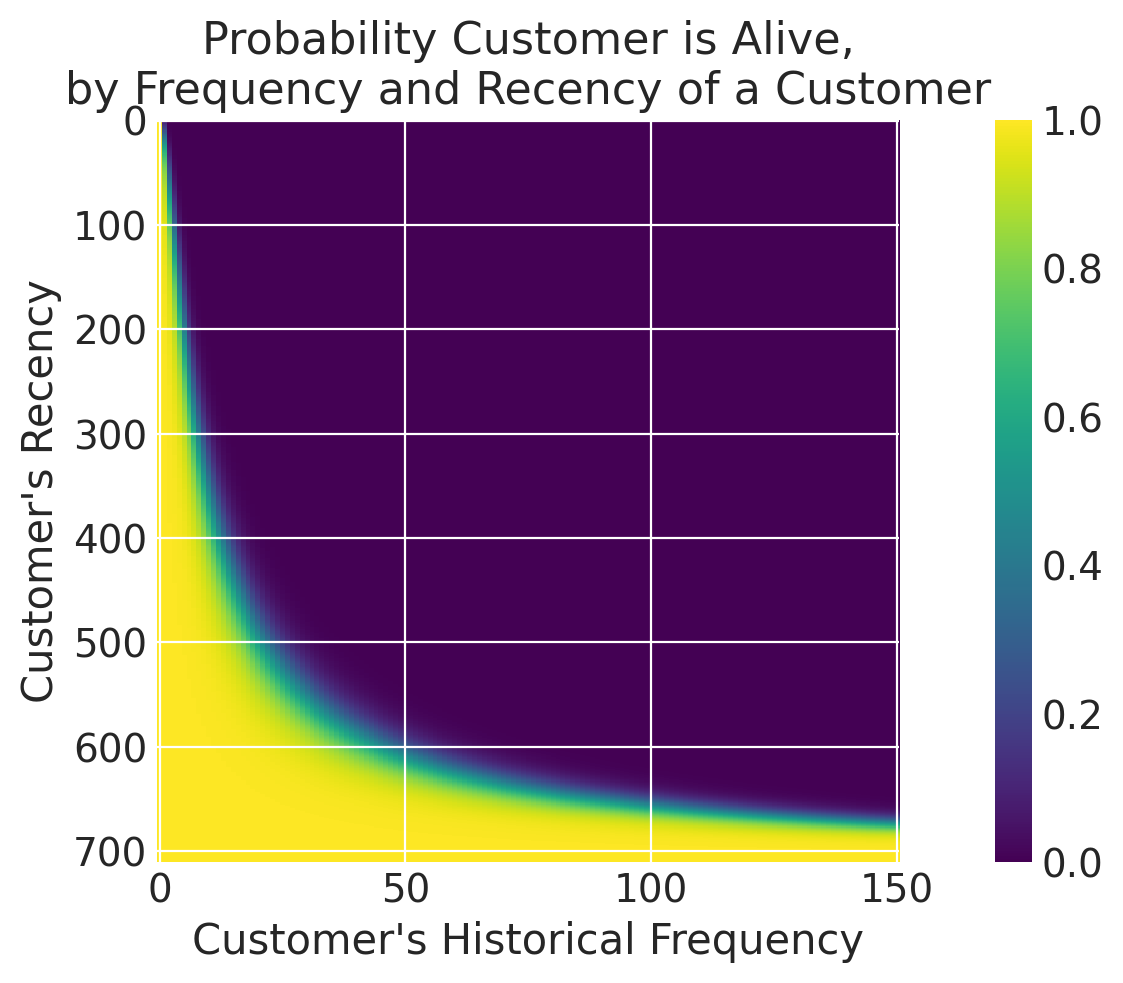

In [21]:
# The Probability Alive Matrix visualizes the likelihood of customers still being active. This view is essential for identifying potentially lost customers and understanding overall customer retention.
# Same frequency cap as above (readability + bounded memory over the posterior).
clv.plot_probability_alive_matrix(bgm, max_frequency=150);

Looking at the probability alive matrix, we can infer that users who have made a lot of purchases a long time ago are likely to never return.

### Predict the number of purchases

In [22]:
# Predicting future purchases within the next 365 days using the fitted model.

num_purchases = bgm.expected_purchases(future_t=365)

In [23]:
# We add expected purchases to our data summary and display the customers with the highest expected purchases.

sdata = data_summary.copy()
sdata["expected_purchases"] = num_purchases.mean(("chain", "draw")).values
sdata.sort_values(by="expected_purchases").tail(4)

,customer_id,frequency,recency,T,monetary_value,expected_purchases
customer_id,,,,,,
2337,2337,443.0,595.0,597.0,26.377065,256.401943
1795,1795,493.0,621.0,622.0,19.777201,273.824025
1510,1510,503.0,629.0,629.0,22.285030,276.376705
900,900,520.0,649.0,649.0,31.547212,277.116558


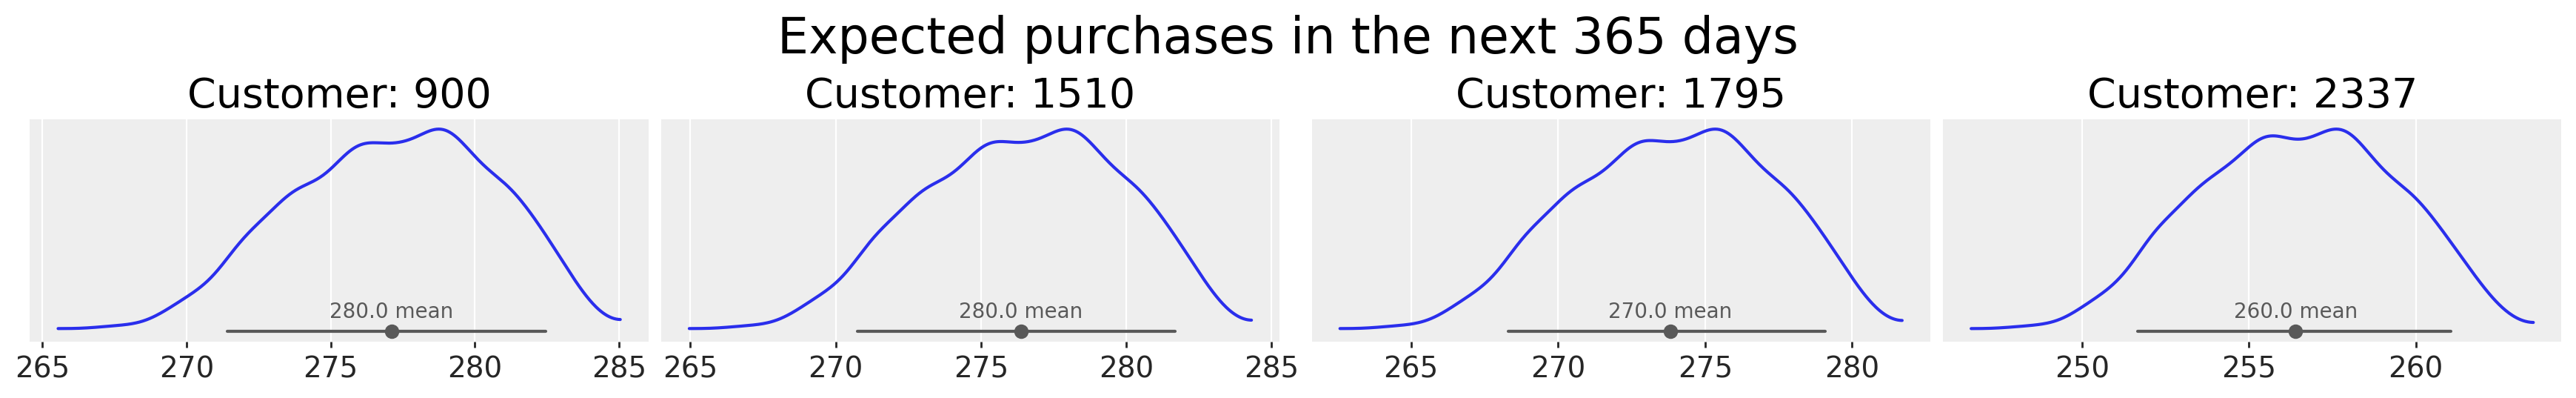

In [24]:
# Here, we're visualizing the uncertainty in our predictions for the number of purchases.
# This step illustrates the range of likely outcomes, highlighting the probabilistic nature of our predictions.

ids = sdata.sort_values(by="expected_purchases", ascending=False).head(4)['customer_id'].tolist()
purchase_pc = azp.plot_dist(
    num_purchases.sel(customer_id=ids).to_dataset(name="x"),
    group=None,
)
for customer_id in ids:
    purchase_pc.get_viz(
        "plot", var_name="x", customer_id=customer_id
    ).set_title(f"Customer: {customer_id}", size=20)
purchase_pc.add_title("Expected purchases in the next 365 days", size=24);

### Predicting purchase behavior of a new customer

We can use the fitted model to predict the number of purchases for a fresh new customer.

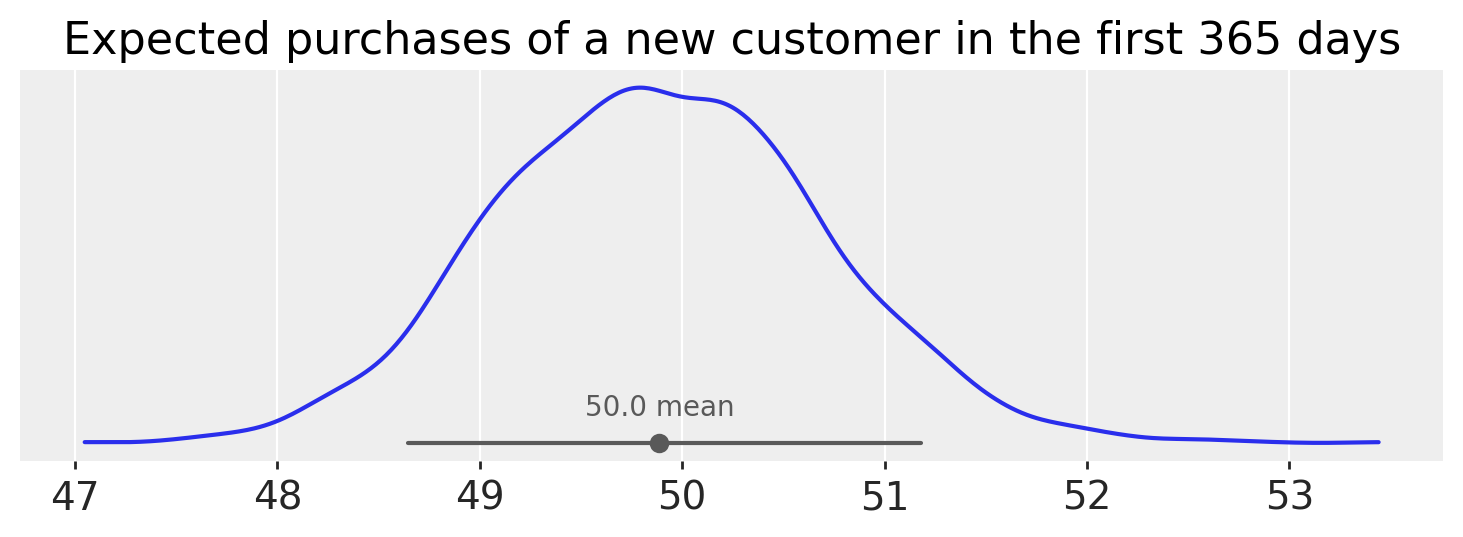

In [25]:
# Estimating the purchasing behavior of a completely new customer.
# This prediction is useful for understanding what purchasing behavior might be expected from prospective customers.

# v1.0 broadcasts this population-level posterior across the fitted
# `customer_id` coordinate. Every slice is identical, so keep one copy before
# plotting rather than asking arviz-plots to create one panel per customer.
new_customer_purchases = bgm.expected_purchases_new_customer(t=365).isel(
    customer_id=0,
    drop=True,
)
new_purchase_pc = azp.plot_dist(
    new_customer_purchases.to_dataset(name="x"),
    group=None,
)
new_purchase_pc.get_viz("plot", var_name="x").set_title(
    "Expected purchases of a new customer in the first 365 days"
);

### Customer Probability Histories

Given a customer transaction history, we can calculate their historical probability of being alive, according to our trained model. 

In [26]:
# Selecting a high-frequency customer to visualize their transaction history
# and model their future transaction probability.

# Pick the customer with the highest frequency from our data
customer_id_viz = data_summary.sort_values('frequency', ascending=False).iloc[0]['customer_id']
customer_viz = data_summary.loc[customer_id_viz]
print(f"Selected customer: {customer_id_viz}")
customer_viz  # Displaying the selected customer's historical summary.

Selected customer: 900


customer_id             900
frequency             520.0
recency               649.0
T                     649.0
monetary_value    31.547212
Name: 900, dtype: object

In [27]:
# Define the range of T values to simulate the customer's probability of being alive over time.
# The new API requires unique customer_id per call, so we loop over each time step.

data_range = 30
T_start = int(customer_viz["T"])
steps = range(T_start - 1, T_start + data_range - 1)
freq_base = int(customer_viz["frequency"])
rec_base = customer_viz["recency"]

In [28]:
# Calculating the probability of this customer being still active (alive) using the BG/NBD model.
# We call expected_probability_alive once per time step with a unique customer_id.

p_alive_list = []
T_values = []
for i, t_val in enumerate(steps):
    single_row = pd.DataFrame({
        "customer_id": [f"{customer_id_viz}_t{i}"],
        "frequency": [freq_base],
        "recency": [rec_base],
        "T": [t_val],
    })
    pa = bgm.expected_probability_alive(data=single_row)
    p_alive_list.append(pa.values)
    T_values.append(t_val)

# Stack results into a single array: shape (n_chains, n_draws, n_steps)
p_alive_arr = np.concatenate(p_alive_list, axis=-1)
T_values = np.array(T_values)

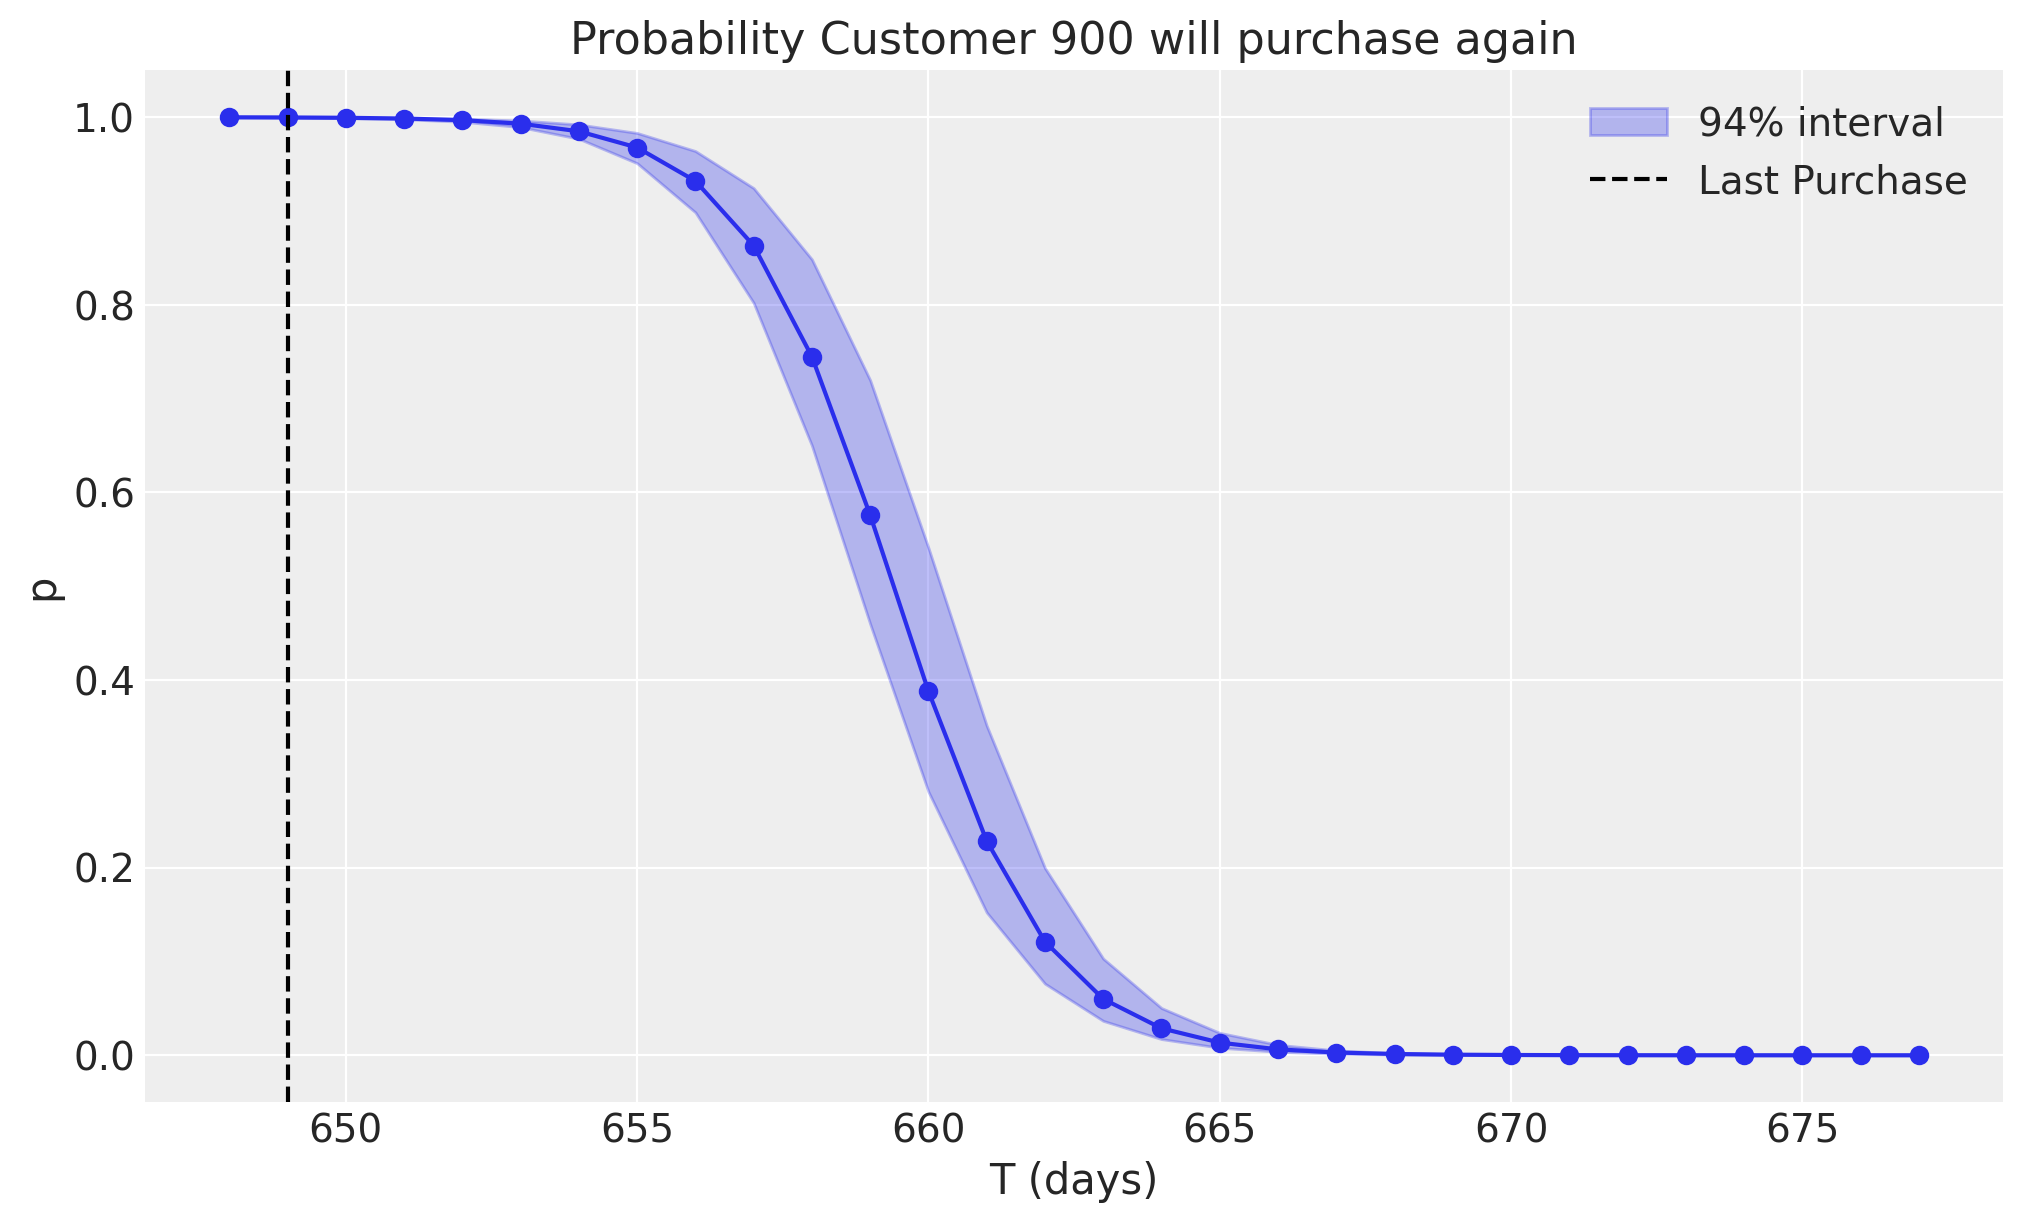

In [29]:
# Visualizing the customer's probability of remaining active over the forecasted period.
# The shaded area represents the confidence interval, providing a range where the actual probability is likely to fall.

# p_alive_arr shape: (chains, draws, steps) — flatten chains*draws for quantiles
p_alive_flat = p_alive_arr.reshape(-1, len(T_values))  # (chains*draws, steps)

lower, upper = np.quantile(p_alive_flat, [0.03, 0.97], axis=0)
plt.figure(figsize=(10, 6))
plt.fill_between(T_values, lower, upper, alpha=0.3, color="C0", label="94% interval")
plt.plot(T_values, p_alive_flat.mean(axis=0), marker="o")
plt.axvline(rec_base, c="black", ls="--", label="Last Purchase")

plt.title(f"Probability Customer {customer_id_viz} will purchase again")
plt.xlabel("T (days)")
plt.ylabel("p")
plt.legend();

Note: The plot suggests that the likelihood of a customer returning decreases the longer they go without making a purchase.

In [30]:
# Now, let's simulate a scenario where the customer makes an additional purchase during the forecast period.
# We increment frequency and update recency for the last 10 time steps.

purchase_step = 20  # The customer makes a purchase at step 20 (i.e., 20 days into the forecast)
new_rec = T_values[purchase_step] - 0.5
new_freq = freq_base + 1

In [31]:
# Recalculating the probability of being alive based on the updated transaction history.
# Before the purchase step: same as before. After: frequency+1 and updated recency.

p_alive_list2 = []
for i, t_val in enumerate(steps):
    if i < purchase_step:
        f, r = freq_base, rec_base
    else:
        f, r = new_freq, new_rec
    single_row = pd.DataFrame({
        "customer_id": [f"{customer_id_viz}_t{i}"],
        "frequency": [f],
        "recency": [r],
        "T": [t_val],
    })
    pa = bgm.expected_probability_alive(data=single_row)
    p_alive_list2.append(pa.values)

p_alive_arr2 = np.concatenate(p_alive_list2, axis=-1)

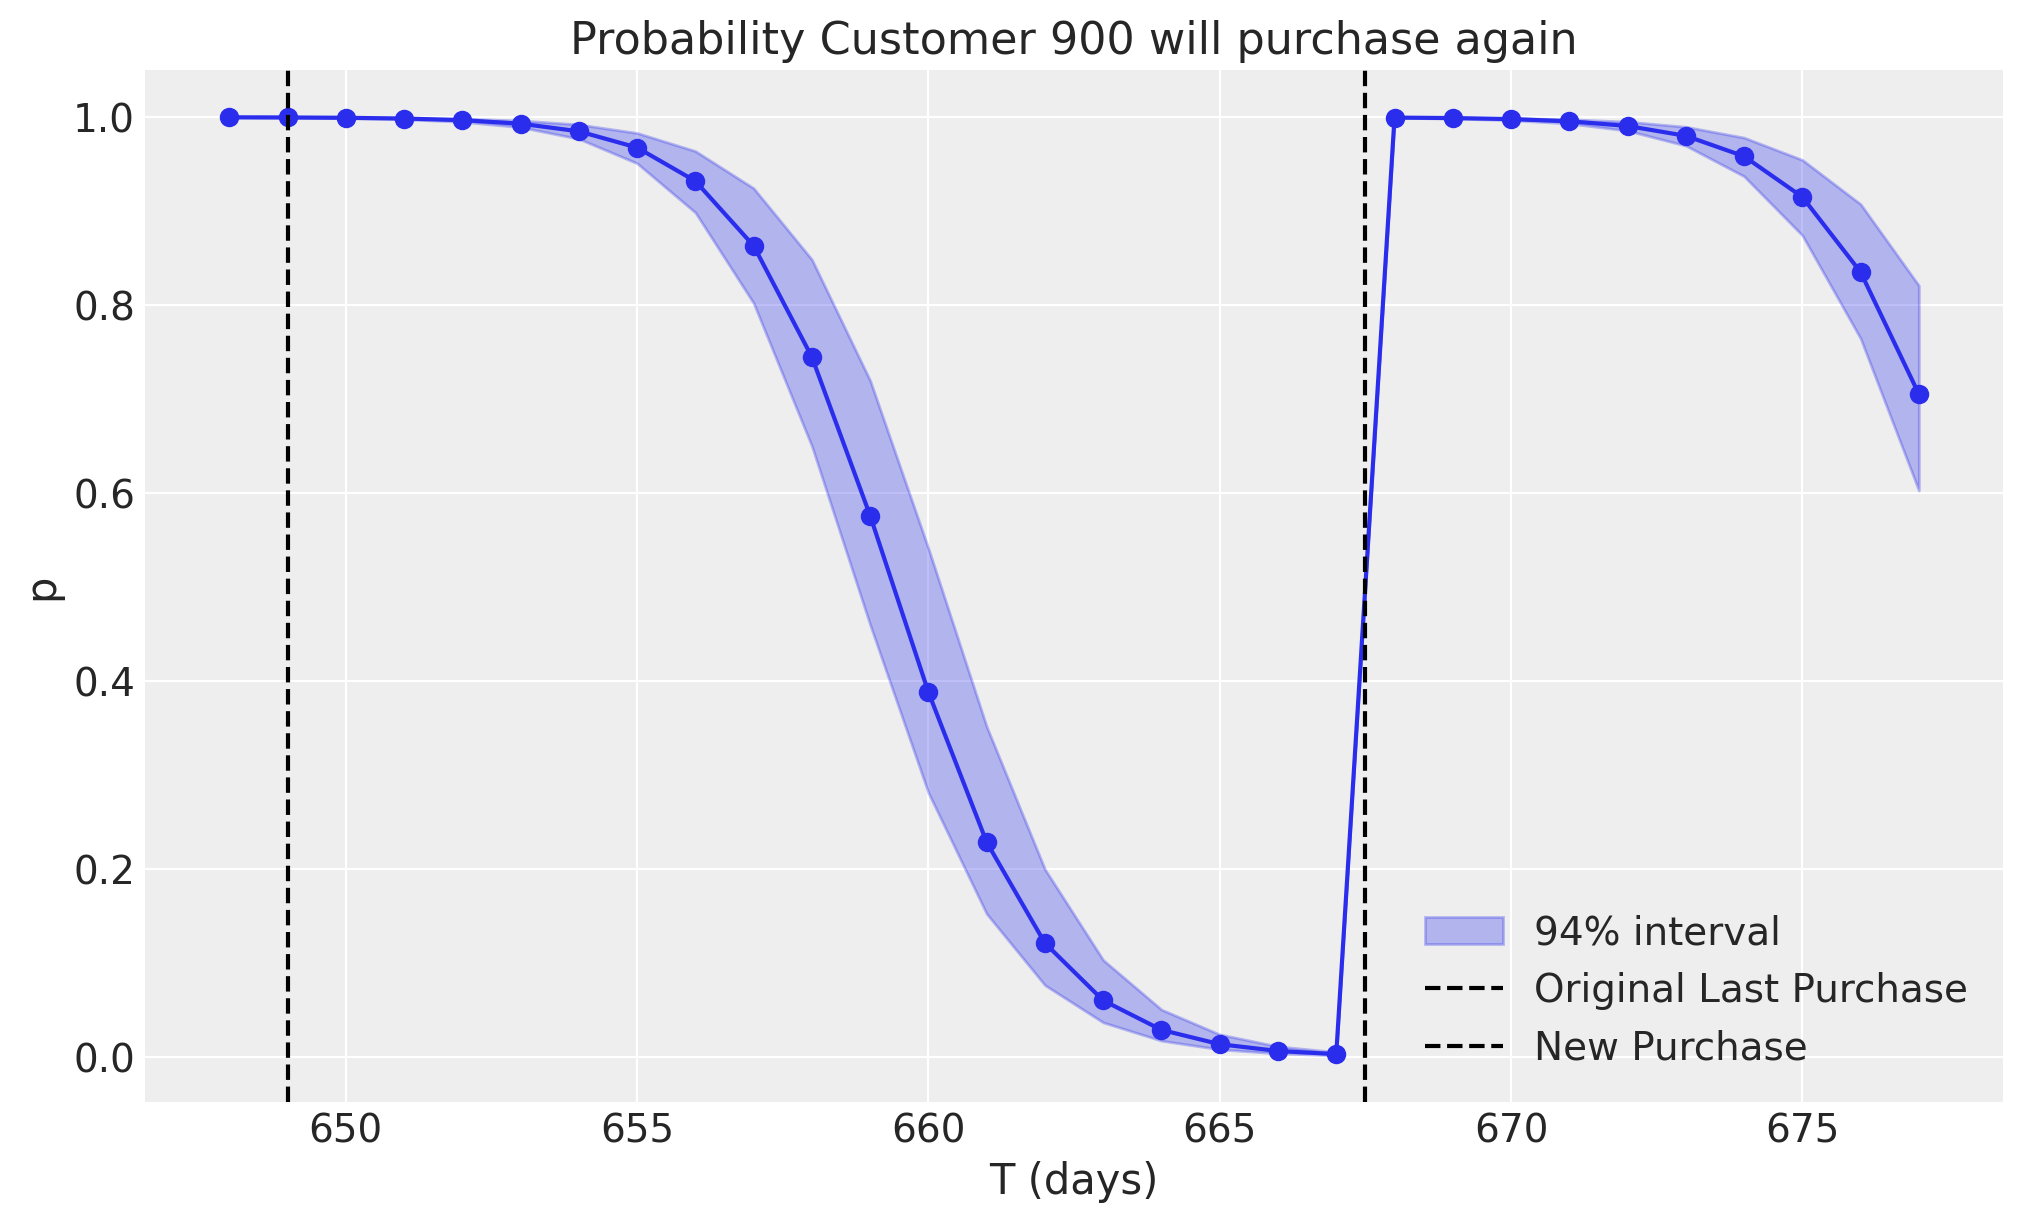

In [32]:
# Plotting the revised probability of the customer remaining active.
# The new purchase is marked, indicating its positive impact on the customer's likelihood of returning for more purchases.

p_alive_flat2 = p_alive_arr2.reshape(-1, len(T_values))

lower2, upper2 = np.quantile(p_alive_flat2, [0.03, 0.97], axis=0)
plt.figure(figsize=(10, 6))
plt.fill_between(T_values, lower2, upper2, alpha=0.3, color="C0", label="94% interval")
plt.plot(T_values, p_alive_flat2.mean(axis=0), marker="o")
plt.axvline(rec_base, c="black", ls="--", label="Original Last Purchase")
plt.axvline(new_rec, c="black", ls="--", label="New Purchase")

plt.title(f"Probability Customer {customer_id_viz} will purchase again")
plt.xlabel("T (days)")
plt.ylabel("p")
plt.legend();

From the plot above, say that this customer makes a purchase roughly ~20 days after the end of the observation period. We can see that the probability of the customer returning quickly goes back up!

In other words, for every purchase, the probability of a customer returning for a/more purchase(s) increases. Similarly, as time goes by where a customer makes no purchase, the likelihood of them returning for a purchase decreases with time.

# Gamma-Gamma model


The Gamma-Gamma model estimates the monetary value aspect of customer lifetime value (CLV).
This model assumes that while customers have different average transaction values, the variation in transaction value among transactions is independent of the variation between customers.

It also assumes that how *often* a customer buys carries no information about how *much* they
spend per order. A simple linear diagnostic is available, so we check it before fitting.


In [33]:
# Filtering out customers with zero frequency to fit the Gamma-Gamma model.
# This model requires customers to have made at least one repeat purchase.
# We also drop non-positive spend: PyMC-Marketing 1.0 raises
# `ValueError("Column monetary_value contains zeroes or negative values")` on
# such rows. Here the guard is a no-op (every `frequency > 0` household already
# has positive spend), but it makes the filter explicit for other datasets.

nonzero_data = data_summary.query("frequency > 0 and monetary_value > 0")
nonzero_data

,customer_id,frequency,recency,T,monetary_value
customer_id,,,,,
1,1,77.0,655.0,660.0,55.214286
10,10,4.0,571.0,597.0,44.947500
100,100,27.0,685.0,705.0,82.451852
1000,1000,126.0,657.0,662.0,32.721746
1001,1001,78.0,694.0,695.0,51.830256
...,...,...,...,...,...
995,995,20.0,633.0,641.0,60.492500
996,996,125.0,697.0,697.0,17.678400
997,997,85.0,678.0,678.0,54.261412


In [34]:
# A near-zero Pearson correlation is a useful diagnostic for Gamma-Gamma's
# frequency-value independence assumption, but it cannot prove full
# independence. A material correlation is a warning to revisit the spend-model
# specification rather than a hard pass/fail threshold.

freq_value_corr = nonzero_data[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"Frequency vs monetary_value correlation: {freq_value_corr:.3f}")

Frequency vs monetary_value correlation: -0.017


PyMC-Marketing 1.0 uses weakly informative Weibull defaults for Gamma-Gamma:
`p, q ~ Weibull(2, 1)` and `v ~ Weibull(2, 10)`. We use those defaults here;
domain-specific alternatives can be supplied through `model_config` in the
same way as for BG/NBD.

In [35]:
# Preparing the data for the Gamma-Gamma model. The API expects columns:
# customer_id, frequency, and monetary_value.

dataset = nonzero_data[["customer_id", "frequency", "monetary_value"]]

In [36]:
# Initializing the Gamma-Gamma model.

gg = clv.GammaGammaModel()
gg

Gamma-Gamma Model (Mean Transactions)

By default, `fit` approximates the full Bayesian posterior using [MCMC](https://en.wikipedia.org/wiki/Markov_chain_Monte_Carlo) sampling provided by `pymc.sample`. If the full posterior is not needed or MCMC sampling is too slow, users can obtain the single [maximum a posteriori estimate](https://en.wikipedia.org/wiki/Maximum_a_posteriori_estimation) via the `method` kwarg.

In [37]:
# Fitting the Gamma-Gamma model via NUTS so we get a posterior for AOV, not just
# a point estimate. The Gamma-Gamma model is small (3 parameters); sampling
# completes in roughly a minute even on a laptop.

gg.fit(
    data=dataset,
    chains=4,
    draws=1000,
    tune=1000,
    target_accept=0.95,
    random_seed=SEED,
    progressbar=False,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p, q, v]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1140 seconds.


<xarray.DataTree>
Group: /
│   Attributes:
│       id:              979051a13083df82
│       model_type:      Gamma-Gamma Model (Mean Transactions)
│       version:         None
│       sampler_config:  {}
│       model_config:    {"p": {"dist": "Weibull", "kwargs": {"alpha": 2, "beta":...
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           p        (chain, draw) float64 32kB 2.149 2.2 2.183 ... 2.464 2.427 2.324
│           q        (chain, draw) float64 32kB 3.177 3.174 3.193 ... 3.016 3.025 3.014
│           v        (chain, draw) float64 32kB 38.09 38.07 37.92 ... 31.99 32.53 33.36
│       Attributes:
│           created_at:                 2026-08-25T02:32:39.979920+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1140.42471408844
│           tuning_steps:               1000
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           perf_counter_start     (chain, draw) float64 32kB 3.63e+05 ... 3.633e+05
│           lp                     (chain, draw) float64 32kB -1.089e+04 ... -1.089e+04
│           max_energy_error       (chain, draw) float64 32kB -0.08877 ... 0.04988
│           step_size_bar          (chain, draw) float64 32kB 0.06856 ... 0.06514
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           index_in_trajectory    (chain, draw) int64 32kB 33 -3 -4 1 ... -21 49 7 4
│           ...                     ...
│           energy                 (chain, draw) float64 32kB 1.089e+04 ... 1.089e+04
│           step_size              (chain, draw) float64 32kB 0.07552 ... 0.05502
│           process_time_diff      (chain, draw) float64 32kB 0.5205 0.03236 ... 0.2475
│           acceptance_rate        (chain, draw) float64 32kB 0.9999 0.8272 ... 0.9814
│           perf_counter_diff      (chain, draw) float64 32kB 0.5577 0.03375 ... 0.249
│           energy_error           (chain, draw) float64 32kB -0.01264 ... 0.04613
│       Attributes:
│           created_at:                 2026-08-25T02:32:39.992085+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1140.42471408844
│           tuning_steps:               1000
├── Group: /observed_data
│       Attributes:
│           created_at:                 2026-08-25T02:32:39.996334+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /fit_data
        Dimensions:         (customer_id: 2497)
        Coordinates:
          * customer_id     (customer_id) object 20kB '1' '10' '100' ... '998' '999'
        Data variables:
            frequency       (customer_id) float64 20kB 77.0 4.0 27.0 ... 85.0 188.0 45.0
            monetary_value  (customer_id) float64 20kB 55.21 44.95 82.45 ... 44.04 47.62

In [38]:
# Convergence diagnostics for Gamma-Gamma: r_hat ≤ 1.01 and divergences ≈ 0.
# `fit_summary` returns the table — keep it as the last expression to render it.

n_divergent_gg = int(gg.idata.sample_stats["diverging"].sum().item())
print(f"Gamma-Gamma divergences: {n_divergent_gg}")
gg.fit_summary()

Gamma-Gamma divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p,2.09,0.26,1.7,2.5,971,1118,1.00,0.0085,0.0071
q,3.034,0.084,2.9,3.2,1506,1538,1.00,0.0022,0.0015
v,38.3,4.8,31,46,913,1151,1.00,0.16,0.11


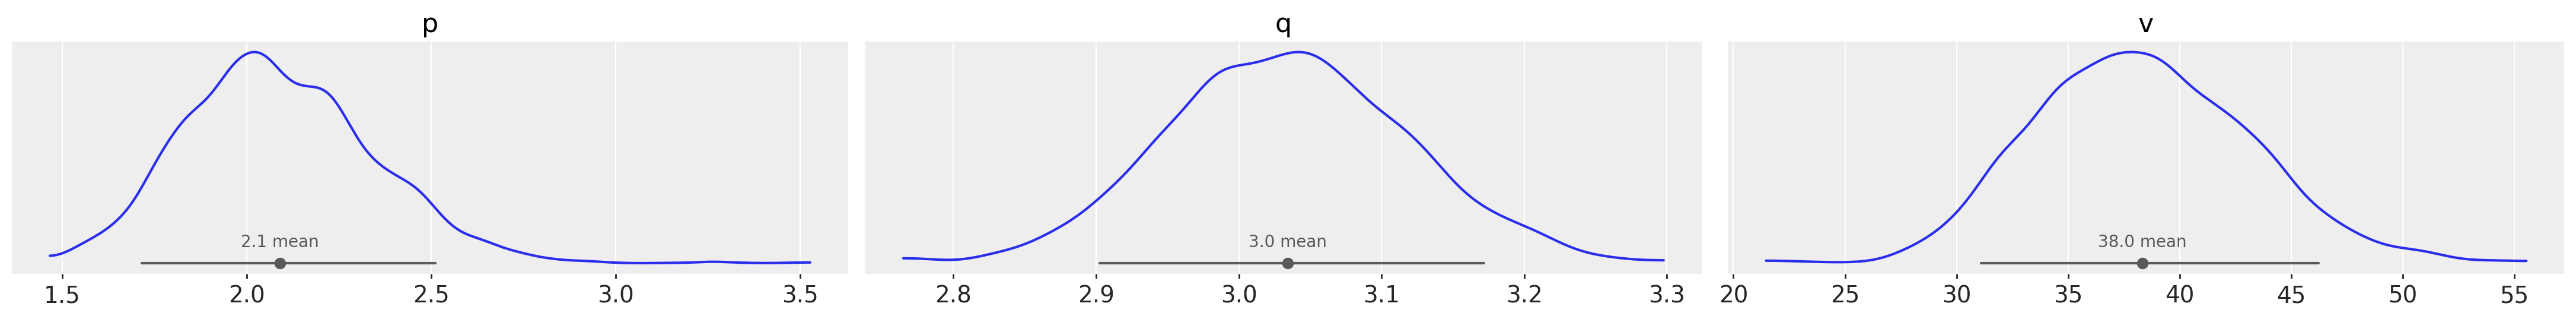

In [39]:
# Posterior distributions of the AOV parameters. Note: the downstream
# `expected_customer_lifetime_value` call summarizes this spend posterior to its
# mean (a scalar `future_spend` per customer) before discounting, so the CLV
# intervals reflect transaction-model (BG/NBD) uncertainty only, not spend
# uncertainty.

azp.plot_dist(gg.idata, var_names=["p", "q", "v"]);

### Predicting Customer Spending

Having fit our model, we can now use it to predict the conditional, expected average order value of our customers.

In [40]:
# Calculating the conditional expected average order value for each customer.

expected_spend = gg.expected_customer_spend(
    data=data_summary[["customer_id", "monetary_value", "frequency"]],
)

In [41]:
# Summarizing the expected statistics of average order value for the first ten customers.

az.summary(
    expected_spend.isel(customer_id=range(10)),
    kind="stats",
    ci_prob=0.94,
    ci_kind="hdi",
)

,mean,sd,hdi94_lb,hdi94_ub
x[1],55,0.029,55,55
x[10],44,0.2,43,44
x[100],81,0.2,81,81
x[1000],33,0.0073,33,33
x[1001],52,0.024,52,52
x[1002],35,0.026,35,35
x[1003],54,0.047,54,54
x[1004],18,0.012,18,18
x[1005],15,0.018,15,15
x[1006],18,0.26,17,18


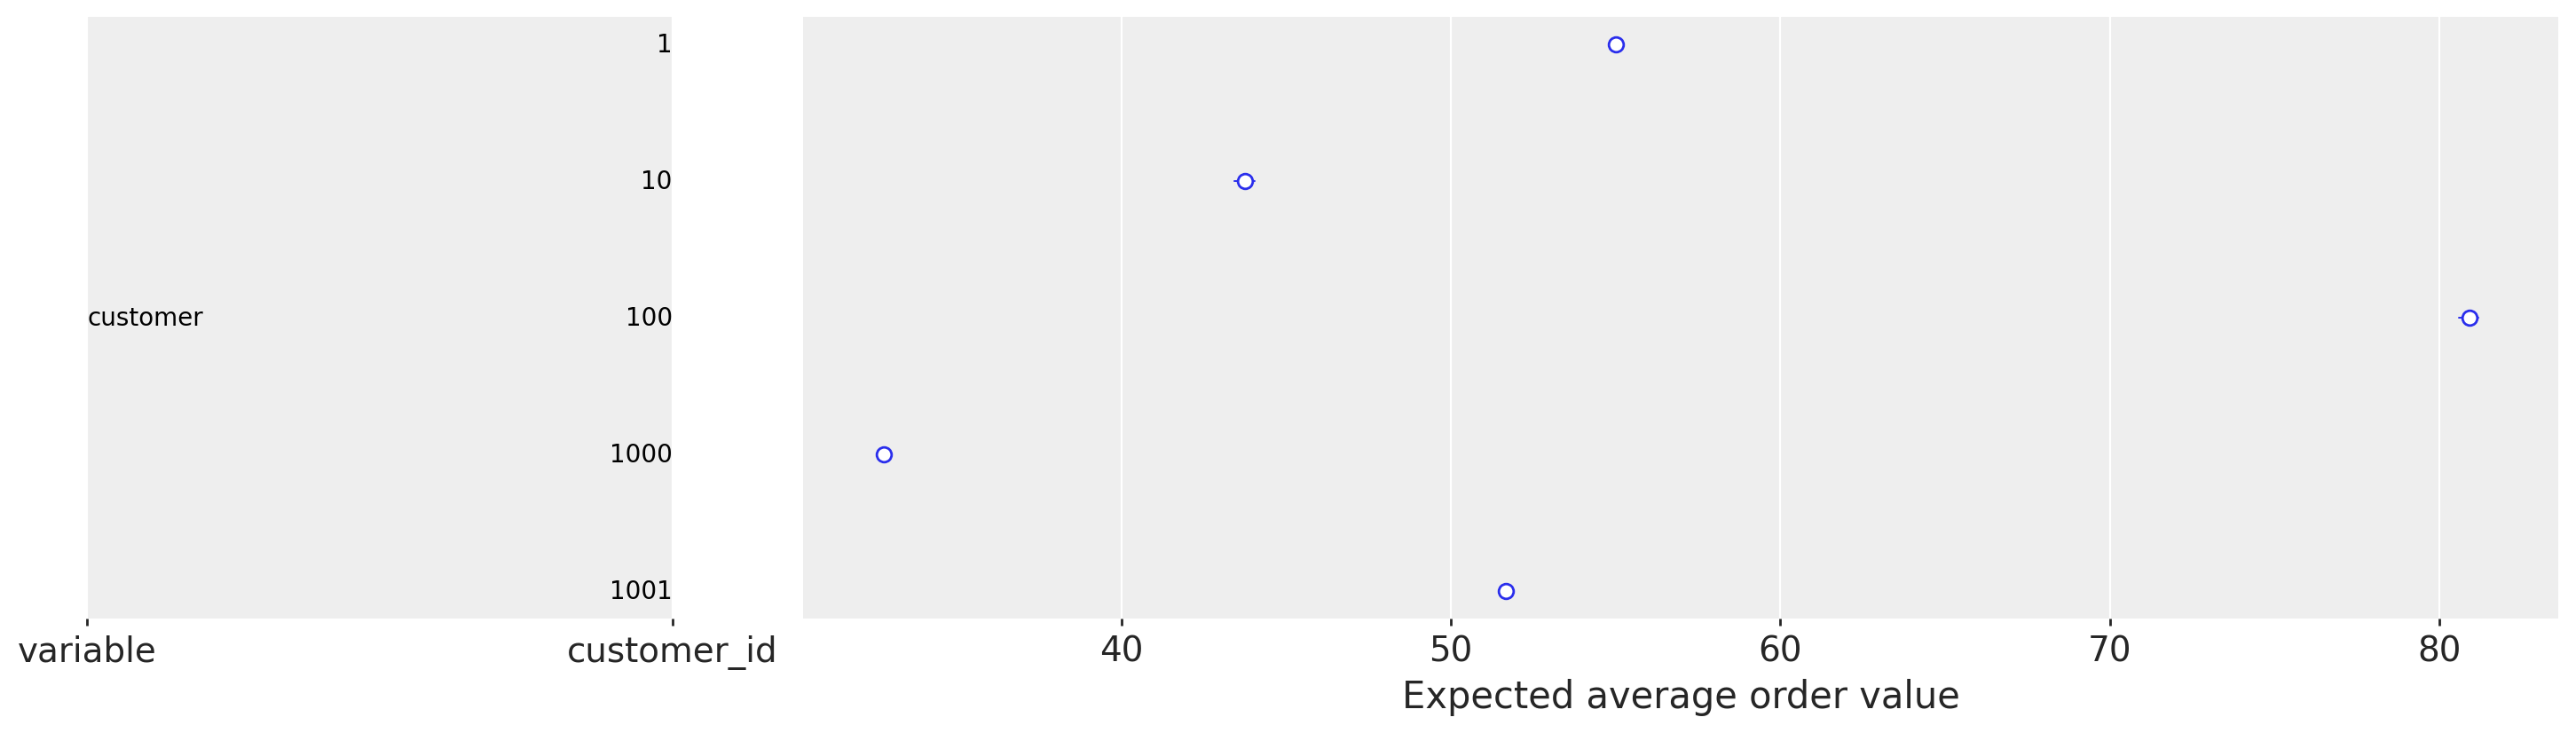

In [42]:
# Creating a forest plot to visualize the expected spend across customers.

labeller = MapLabeller(var_name_map={"x": "customer"})
spend_forest_pc = azp.plot_forest(
    expected_spend.isel(customer_id=range(5)).to_dataset(name="x"),
    group=None,
    combined=True,
    labeller=labeller,
)
spend_forest_pc.get_viz("plot", column="forest").set_xlabel(
    "Expected average order value"
);

We can also look at the average expected average order value across all customers

In [43]:
# Analyzing the overall average expected spend across all customers.
# This aggregate metric provides a broad view, useful for strategic planning and overall revenue forecasting.

az.summary(
    expected_spend.mean("customer_id"),
    kind="stats",
    ci_prob=0.94,
    ci_kind="hdi",
)

,mean,sd,hdi94_lb,hdi94_ub
x,36,0.02,36,36


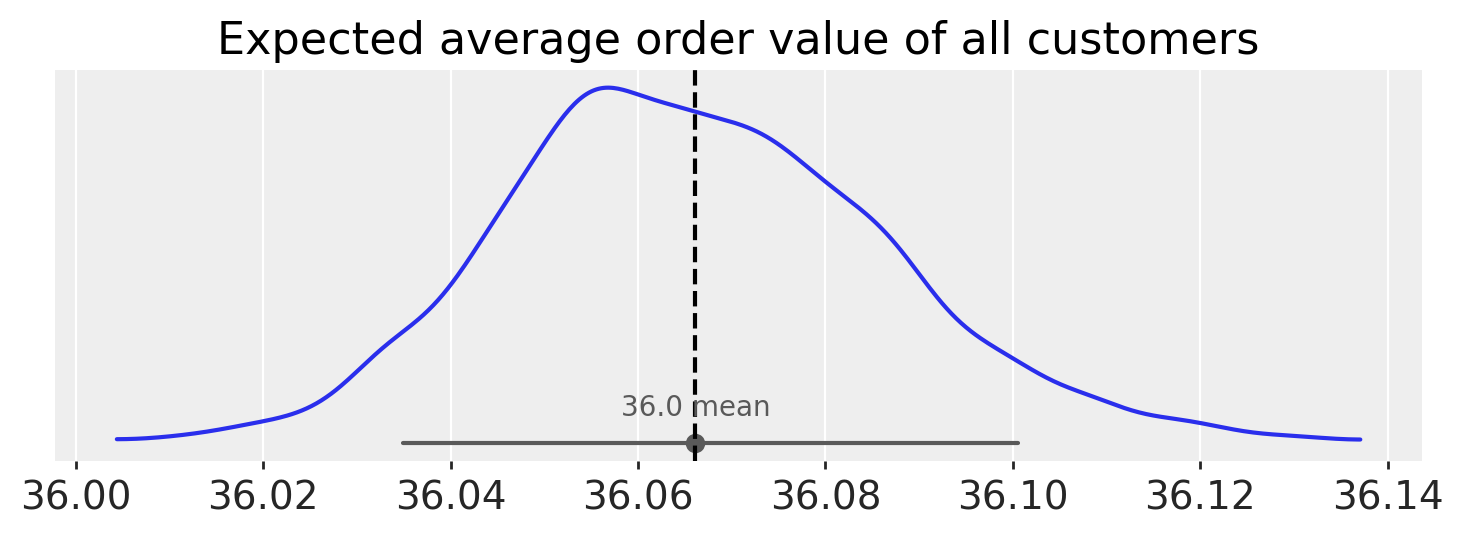

In [44]:
# Plotting the posterior distribution of the average expected spend for all customers.
# The vertical line represents the mean, giving a reference point against the distribution spread.

overall_expected_spend = expected_spend.mean("customer_id")
overall_spend_pc = azp.plot_dist(
    overall_expected_spend.to_dataset(name="x"),
    group=None,
)
overall_spend_ax = overall_spend_pc.get_viz("plot", var_name="x")
overall_spend_ax.axvline(float(overall_expected_spend.mean().item()), color="k", ls="--")
overall_spend_ax.set_title("Expected average order value of all customers");

### Predicting New Customer Spending

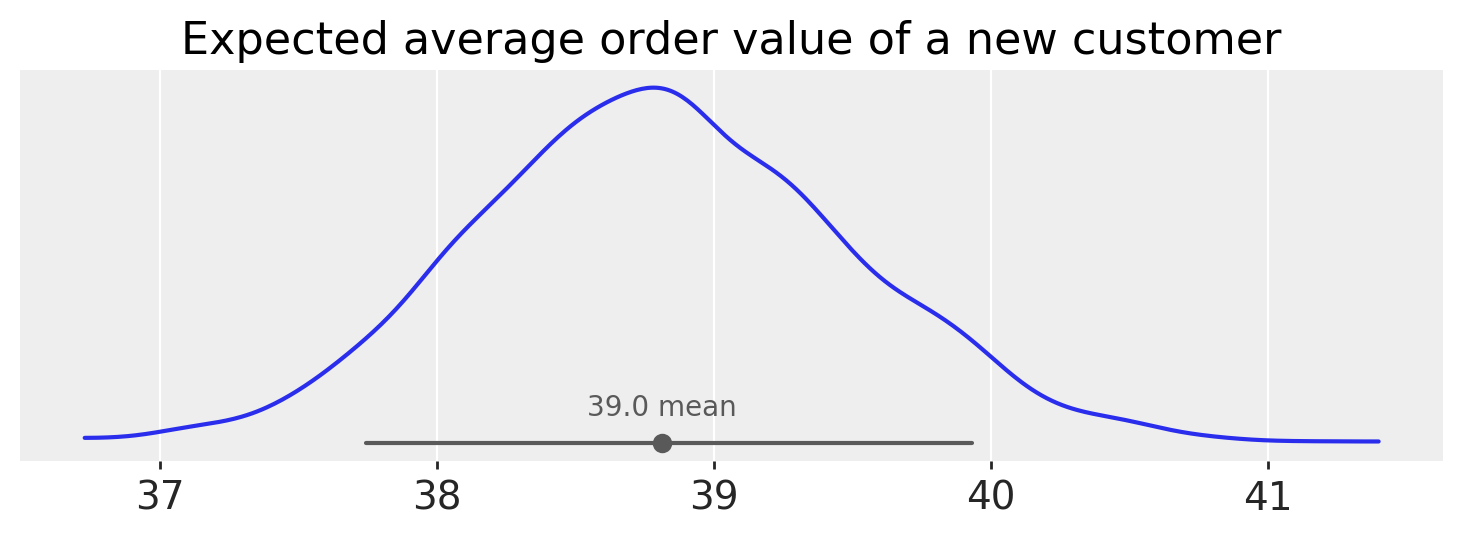

In [45]:
# Estimating the expected average spend of a hypothetical new customer.
# This prediction helps in budgeting and planning marketing strategies for customer acquisition.

new_customer_spend = gg.expected_new_customer_spend()
new_spend_pc = azp.plot_dist(
    new_customer_spend.to_dataset(name="x"),
    group=None,
)
new_spend_pc.get_viz("plot", var_name="x").set_title(
    "Expected average order value of a new customer"
);

### Customer Lifetime Value (CLV) Estimation

Finally, we can combine the GG with the BG/NBD model to obtain an estimate of the customer lifetime value. This relies on the [Discounted cash flow](https://en.wikipedia.org/wiki/Discounted_cash_flow) model, adjusting for cost of capital:

### DCF Parameter Notes

The `expected_customer_lifetime_value` function uses a **Discounted Cash Flow** approach with three key parameters:

- **`future_t=120`**: The prediction horizon, measured in **months** regardless of `time_unit`. So `future_t=120` = 120 months = **10 years**. (See `pymc_marketing.clv.utils` docstring: "`future_t` is measured in months regardless of `time_unit` specified.")
- **`discount_rate=0.01`**: A **monthly** discount rate (approximately 12.7% annualized via `(1.01)^12 - 1`). This reflects the time value of money — a dollar received today is worth more than a dollar received in the future.
- **`time_unit="D"`**: Tells the function that the RFM features (recency, T) are measured in **days**. Internally, this is used to convert daily units to monthly steps for the BG/NBD expected-purchase calculations.

In [46]:
# Estimating CLV using a Discounted Cash Flow approach, factoring in the time value of money with a discount rate.
# This method captures both the frequency and monetary value dimensions of CLV, offering a nuanced view of customer profitability.

import xarray as xr

# Each customer's CLV is independent, so we compute it in customer batches and
# concatenate along `customer_id`. The result is identical to a single call, but
# peak memory scales with the batch size instead of the full customer count.
# The 10-year DCF over the whole posterior is the heaviest step in this
# notebook; batching keeps it reproducible on a laptop rather than allocating
# tens of GB at once.
CLV_BATCH_SIZE = 500
_clv_cols = ["customer_id", "frequency", "recency", "T", "monetary_value"]


def expected_clv_batched(transaction_model, data, batch_size=CLV_BATCH_SIZE, **kwargs):
    parts = [
        gg.expected_customer_lifetime_value(
            transaction_model=transaction_model,
            data=data.iloc[start:start + batch_size].copy(),
            **kwargs,
        )
        for start in range(0, len(data), batch_size)
    ]
    return xr.concat(parts, dim="customer_id")


clv_estimate = expected_clv_batched(
    bgm,
    data_summary[_clv_cols],
    future_t=120,  # 120 months (10 years) — the headline matched by the qmd
    discount_rate=0.01,
    time_unit="D",
)

In [47]:
# The 10-year DCF can produce inf/NaN posterior samples when the predicted
# purchase rate is extremely high. We mask non-finite samples to NaN and let
# the rest of the pipeline carry NaN through honestly — see the
# `clv_estimation_status` column below.
n_total = clv_estimate.values.size
n_nonfinite = int((~np.isfinite(clv_estimate.values)).sum())
if n_nonfinite > 0:
    pct = n_nonfinite / n_total * 100
    print(f"Masking {n_nonfinite:,} non-finite CLV samples ({pct:.2f}% of {n_total:,} total)")
    clv_estimate = clv_estimate.where(np.isfinite(clv_estimate))

Masking 82,552 non-finite CLV samples (0.83% of 10,000,000 total)


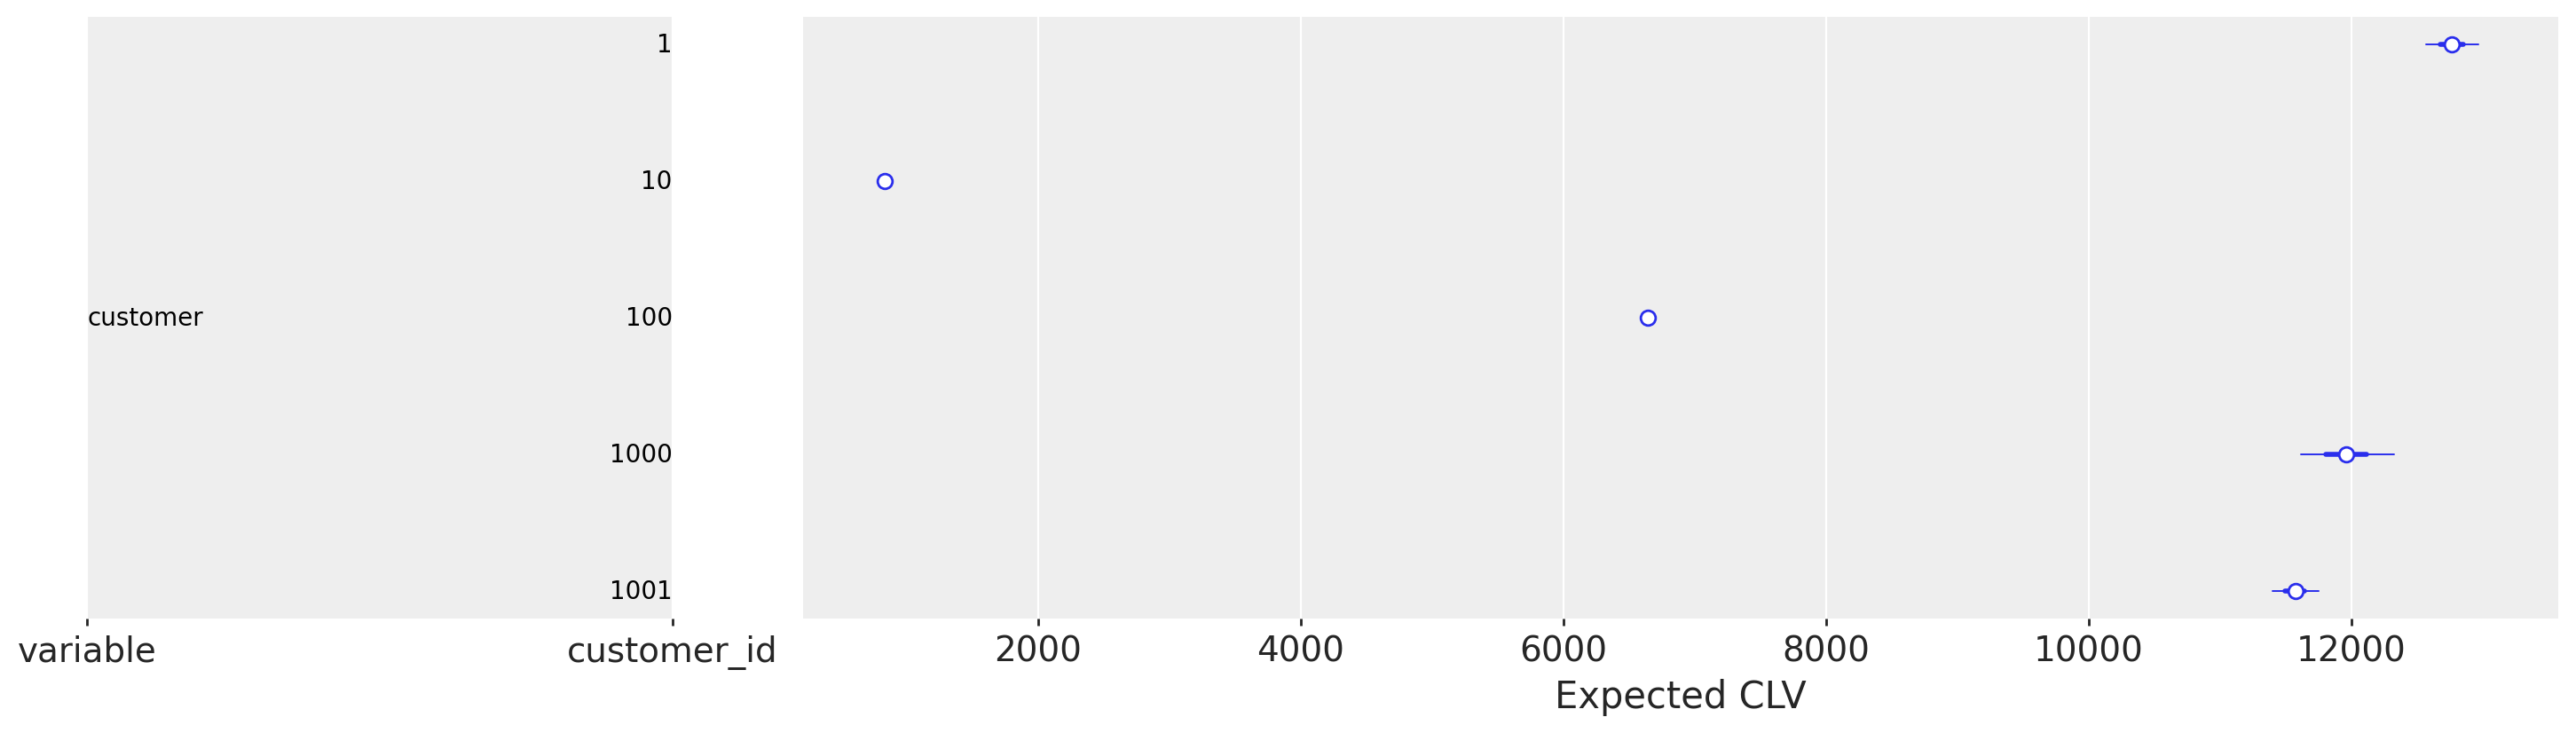

In [48]:
# Visualizing the estimated CLV for a subset of customers.
# The forest plot allows for easy comparison and highlights the variability in the projected CLVs.

clv_forest_pc = azp.plot_forest(
    clv_estimate.isel(customer_id=range(5)).to_dataset(name="x"),
    group=None,
    combined=True,
    labeller=labeller,
)
clv_forest_pc.get_viz("plot", column="forest").set_xlabel("Expected CLV");

In [49]:
# Summarizing the expected CLV for the first ten customers.

az.summary(
    clv_estimate.isel(customer_id=range(10)),
    kind="stats",
    ci_prob=0.94,
    ci_kind="hdi",
)

,mean,sd,hdi94_lb,hdi94_ub
x[1],13000,130,13000,13000
x[10],830,5.6,820,840
x[100],6600,21,6600,6700
x[1000],12000,220,12000,12000
x[1001],12000,110,11000,12000
x[1002],3200,11,3200,3200
x[1003],7500,41,7500,7600
x[1004],11000,400,10000,11000
x[1005],7700,220,7200,8100
x[1006],580,2.1,580,590


### Horizon Sensitivity: 3-year, 5-year, 10-year CLV

The 10-year DCF above is the headline figure the chapter uses, but
horizon choice is itself a decision. Below we re-discount the *same*
posterior over 3- and 5-year horizons so readers can see how much of
the 10-year number is "long-tail extrapolation" versus "value the
model is confident about within the planning window."

`future_t` is in months regardless of `time_unit`. The BG/NBD and
Gamma-Gamma posteriors are already in memory, so each extra horizon
is just the DCF sum — fast.

In [50]:
# 3-year and 5-year CLV (same posterior, shorter discounted horizon).
clv_3y_posterior = expected_clv_batched(
    bgm, data_summary[_clv_cols],
    future_t=36, discount_rate=0.01, time_unit="D",
)
clv_5y_posterior = expected_clv_batched(
    bgm, data_summary[_clv_cols],
    future_t=60, discount_rate=0.01, time_unit="D",
)

# Apply the same non-finite mask as the 10-year posterior.
clv_3y_posterior = clv_3y_posterior.where(np.isfinite(clv_3y_posterior))
clv_5y_posterior = clv_5y_posterior.where(np.isfinite(clv_5y_posterior))

### Exporting and Analyzing CLV Data

We construct the per-customer table directly from the posterior:
- `clv_estimation_status` flags customers whose 10-year posterior was
  *entirely* non-finite (the high-frequency tail where the DCF blew up).
  These rows keep NaN throughout — they are not silently zeroed.
- Every downstream aggregation in this notebook (operating tables,
  CPA ranking, churn watchlist) filters to `status == "ok"` so a
  handful of NaN rows cannot drag a mean to zero.

In [51]:
# Build the per-customer CLV table. NaN-honest: no fillna(0).

# Mark customers where *all* posterior samples were non-finite on the 10y
# horizon. Those are the rows whose 10y CLV is genuinely unrecoverable.
is_all_nonfinite_10y = (~np.isfinite(clv_estimate.values)).all(axis=(0, 1))

clv_mean = clv_estimate.mean(("chain", "draw"), skipna=True)
clv_hdi = az.hdi(clv_estimate, prob=0.94, skipna=True)

clv_df = pd.DataFrame({
    "customer_id": clv_mean.coords["customer_id"].values,
    "clv_estimate": clv_mean.values,                              # NaN where status=='nonfinite_review'
    "clv_estimate_hdi_3%": clv_hdi.sel(ci_bound="lower").values,
    "clv_estimate_hdi_97%": clv_hdi.sel(ci_bound="upper").values,
    "clv_3y_mean": clv_3y_posterior.mean(("chain", "draw"), skipna=True).values,
    "clv_5y_mean": clv_5y_posterior.mean(("chain", "draw"), skipna=True).values,
})
clv_df["clv_estimation_status"] = np.where(
    is_all_nonfinite_10y, "nonfinite_review", "ok"
)
# Horizon multiplier — how much of the 10y headline is past the 3y window?
# Division by NaN propagates NaN, which is the correct behavior here.
clv_df["horizon_multiplier_10y_over_3y"] = (
    clv_df["clv_estimate"] / clv_df["clv_3y_mean"]
)

monetary_values = data_summary.set_index("customer_id").loc[clv_df["customer_id"], "monetary_value"]
clv_df["monetary_value"] = monetary_values.values

# `clv_estimates_output.csv` is written once at the end of the notebook with
# the enriched columns (profit CLV, allowable CPA, segment, churn alert).

n_review = int((clv_df["clv_estimation_status"] == "nonfinite_review").sum())
print(f"Posterior collected for {len(clv_df)} customers "
      f"({n_review} flagged 'nonfinite_review' — see review table below)")

Posterior collected for 2500 customers (19 flagged 'nonfinite_review' — see review table below)


In [52]:
# Surface the review customers. Per the chapter, these should be the
# highest-frequency / longest-tenure households — exactly the ones whose
# 10y DCF lambda samples wandered into instability. Showing them as a
# table is part of being honest about model failure modes.

review_rows = clv_df[clv_df["clv_estimation_status"] == "nonfinite_review"].copy()
if len(review_rows):
    # data_summary has customer_id as both index *and* column, which makes
    # pandas merge raise "ambiguous". Reset the index for a clean join.
    review_rows = review_rows.merge(
        data_summary.reset_index(drop=True)[
            ["customer_id", "frequency", "recency", "T", "monetary_value"]
        ],
        on="customer_id", how="left", suffixes=("", "_summary"),
    )
    print("Customers flagged for review (10y DCF produced all-non-finite posteriors):")
    print("These are the highest-frequency households — do NOT bid $0 on them.")
    display(review_rows.sort_values("frequency", ascending=False).head(20))
else:
    print("No customers flagged — every 10y posterior had at least one finite sample.")

Customers flagged for review (10y DCF produced all-non-finite posteriors):
These are the highest-frequency households — do NOT bid $0 on them.


,customer_id,clv_estimate,clv_estimate_hdi_3%,clv_estimate_hdi_97%,clv_3y_mean,clv_5y_mean,clv_estimation_status,horizon_multiplier_10y_over_3y,monetary_value,frequency,recency,T,monetary_value_summary
17,900,NaN,NaN,NaN,20637.231845,29376.433483,nonfinite_review,NaN,31.547212,520.0,649.0,649.0,31.547212
5,1510,NaN,NaN,NaN,14548.323802,20704.018402,nonfinite_review,NaN,22.285030,503.0,629.0,629.0,22.285030
8,1795,NaN,NaN,NaN,12799.792645,18217.524463,nonfinite_review,NaN,19.777201,493.0,621.0,622.0,19.777201
0,1228,NaN,NaN,NaN,17101.166602,24457.673989,nonfinite_review,NaN,30.941838,468.0,701.0,701.0,30.941838
16,853,NaN,NaN,NaN,17158.868730,24500.819960,nonfinite_review,NaN,29.921022,450.0,645.0,646.0,29.921022
10,2459,NaN,NaN,NaN,24268.091843,34705.788168,nonfinite_review,NaN,45.587439,449.0,669.0,676.0,45.587439
4,1479,NaN,NaN,NaN,11002.214136,15743.621672,nonfinite_review,NaN,20.526712,444.0,685.0,687.0,20.526712
9,2337,NaN,NaN,NaN,15998.563690,22796.598978,nonfinite_review,NaN,26.377065,443.0,595.0,597.0,26.377065
13,762,NaN,NaN,NaN,11822.421106,16872.417564,nonfinite_review,NaN,20.402000,440.0,625.0,625.0,20.402000
18,956,NaN,NaN,NaN,12839.126952,18375.385023,nonfinite_review,NaN,24.498225,417.0,660.0,660.0,24.498225


In [53]:
# Horizon sensitivity summary — does the 10y headline change the
# decile picture, or only the absolute magnitude?

ok_mask = clv_df["clv_estimation_status"] == "ok"
horizon_summary = (
    clv_df.loc[ok_mask, ["clv_3y_mean", "clv_5y_mean", "clv_estimate"]]
    .rename(columns={"clv_estimate": "clv_10y_mean"})
    .describe(percentiles=[0.5, 0.9, 0.99])
    .round(0)
)
print("Revenue CLV by horizon (status=='ok' only):")
print(horizon_summary)
print()
print(f"Median 10y/3y multiplier: "
      f"{clv_df.loc[ok_mask, 'horizon_multiplier_10y_over_3y'].median():.2f}×")
print(f"Mean   10y/3y multiplier: "
      f"{clv_df.loc[ok_mask, 'horizon_multiplier_10y_over_3y'].mean():.2f}×")

Revenue CLV by horizon (status=='ok' only):
       clv_3y_mean  clv_5y_mean  clv_10y_mean
count       2481.0       2481.0        2481.0
mean        4123.0       6030.0        9000.0
std         4303.0       6236.0        9170.0
min            0.0          0.0           0.0
50%         2787.0       4113.0        6214.0
90%         9502.0      13838.0       20570.0
99%        20612.0      29855.0       43607.0
max        52479.0      75171.0      108590.0

Median 10y/3y multiplier: 2.23×
Mean   10y/3y multiplier: 2.22×


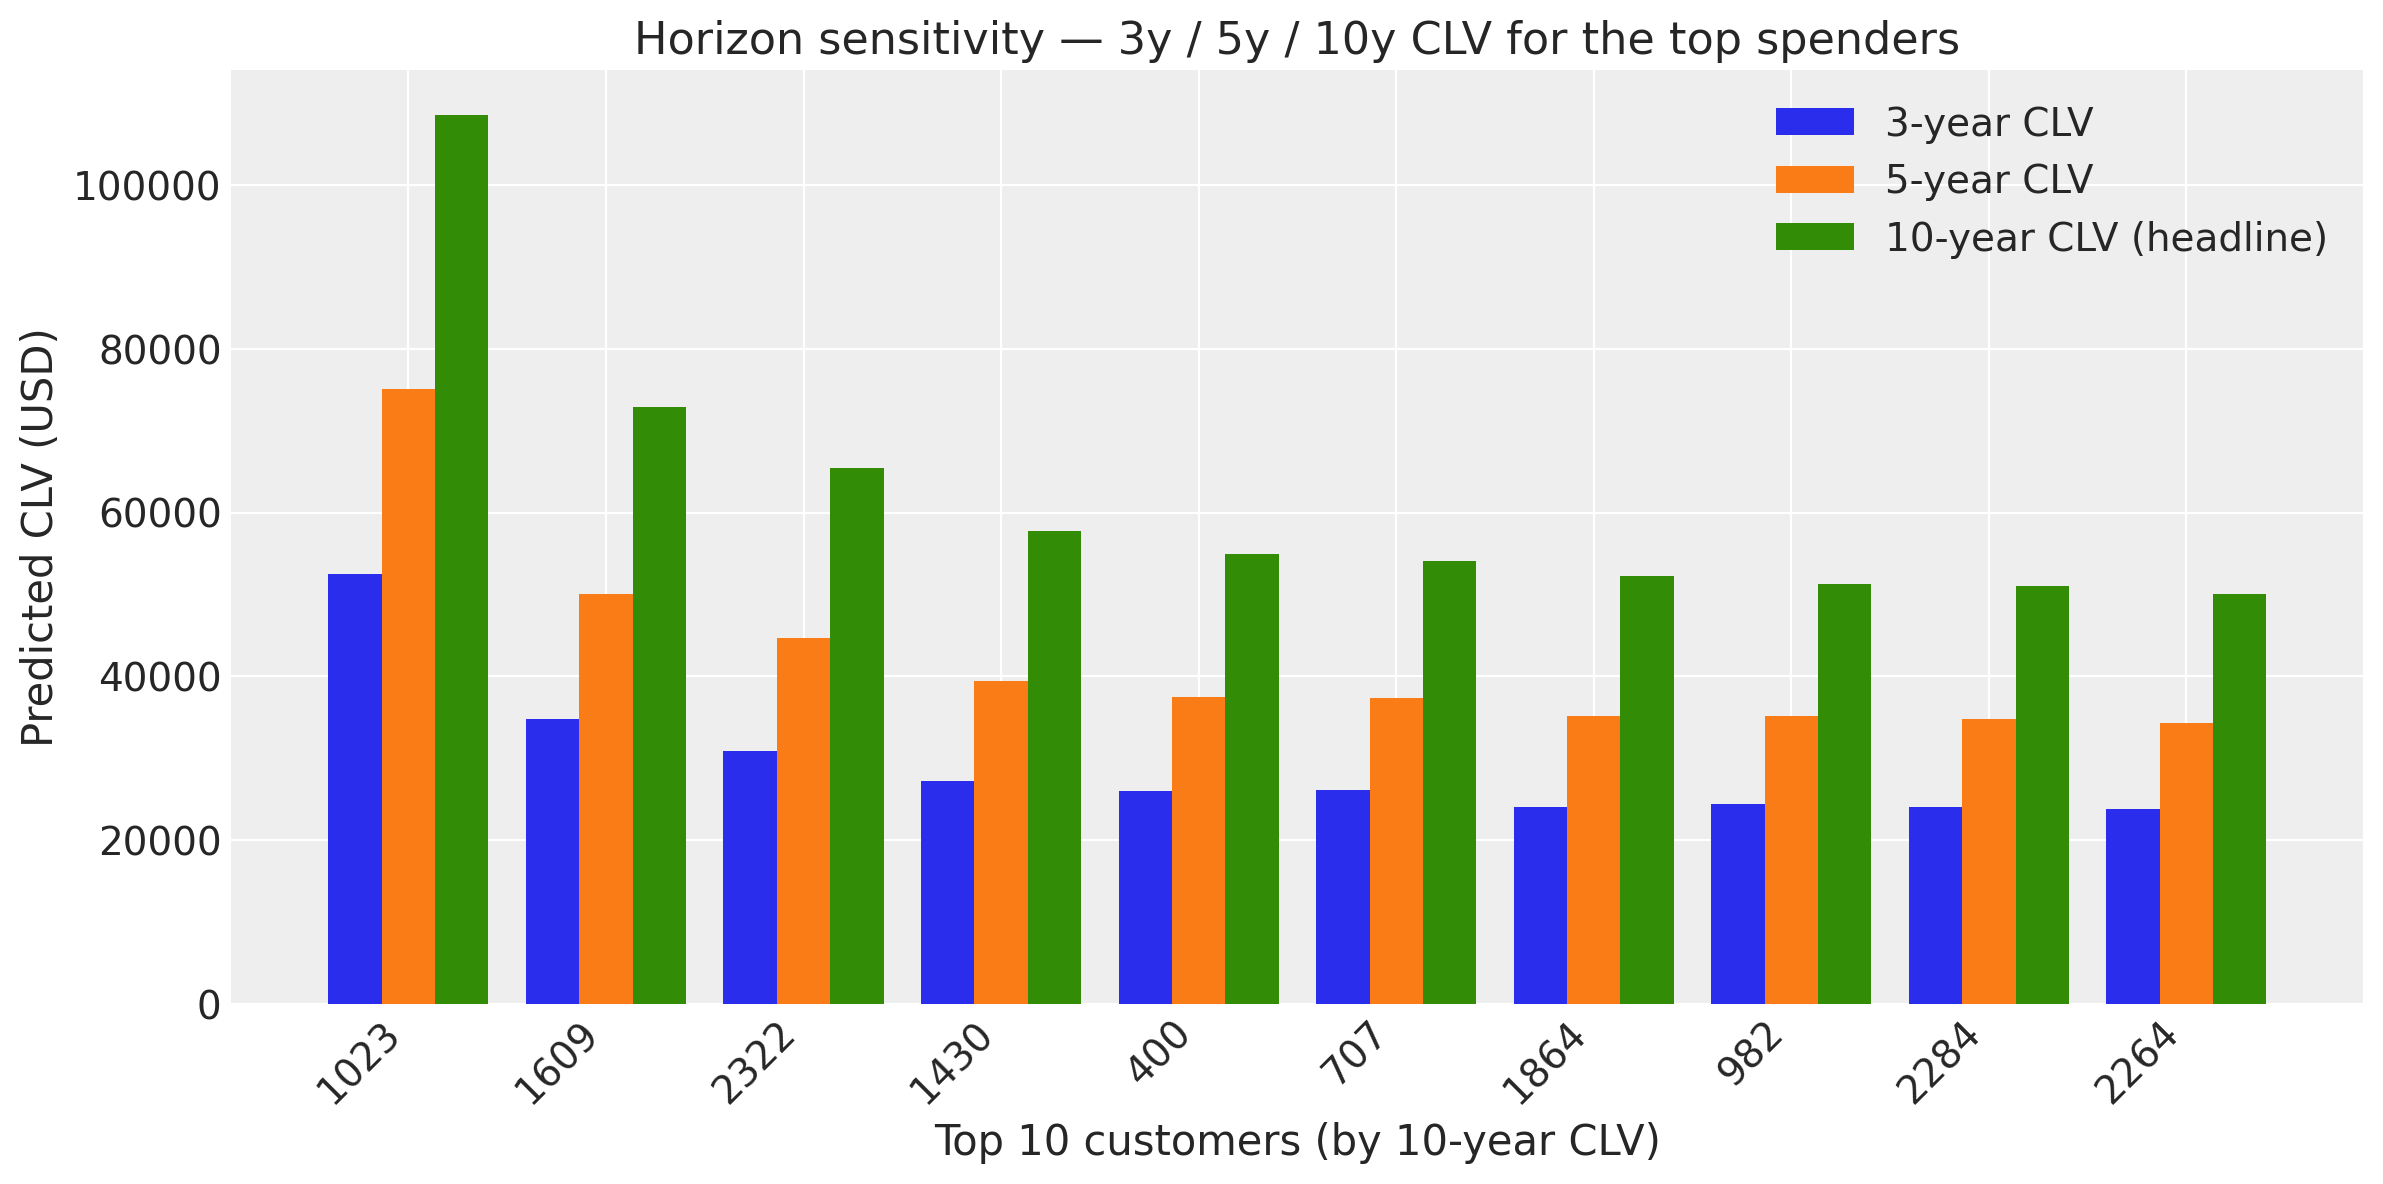

In [54]:
# Top-10 customers visualized across the three horizons. Bars stack
# bottom-up: 3y → 5y → 10y so the reader sees how much the 10y story
# adds on top of the planning-window value.

ok_df = clv_df[ok_mask].copy()
top10 = ok_df.sort_values("clv_estimate", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
idx = np.arange(len(top10))
w = 0.27
ax.bar(idx - w, top10["clv_3y_mean"], w, label="3-year CLV")
ax.bar(idx,     top10["clv_5y_mean"], w, label="5-year CLV")
ax.bar(idx + w, top10["clv_estimate"], w, label="10-year CLV (headline)")
ax.set_xticks(idx)
ax.set_xticklabels(top10["customer_id"].astype(str), rotation=45, ha="right")
ax.set_xlabel("Top 10 customers (by 10-year CLV)")
ax.set_ylabel("Predicted CLV (USD)")
ax.set_title("Horizon sensitivity — 3y / 5y / 10y CLV for the top spenders")
ax.legend()
plt.tight_layout()
plt.show()

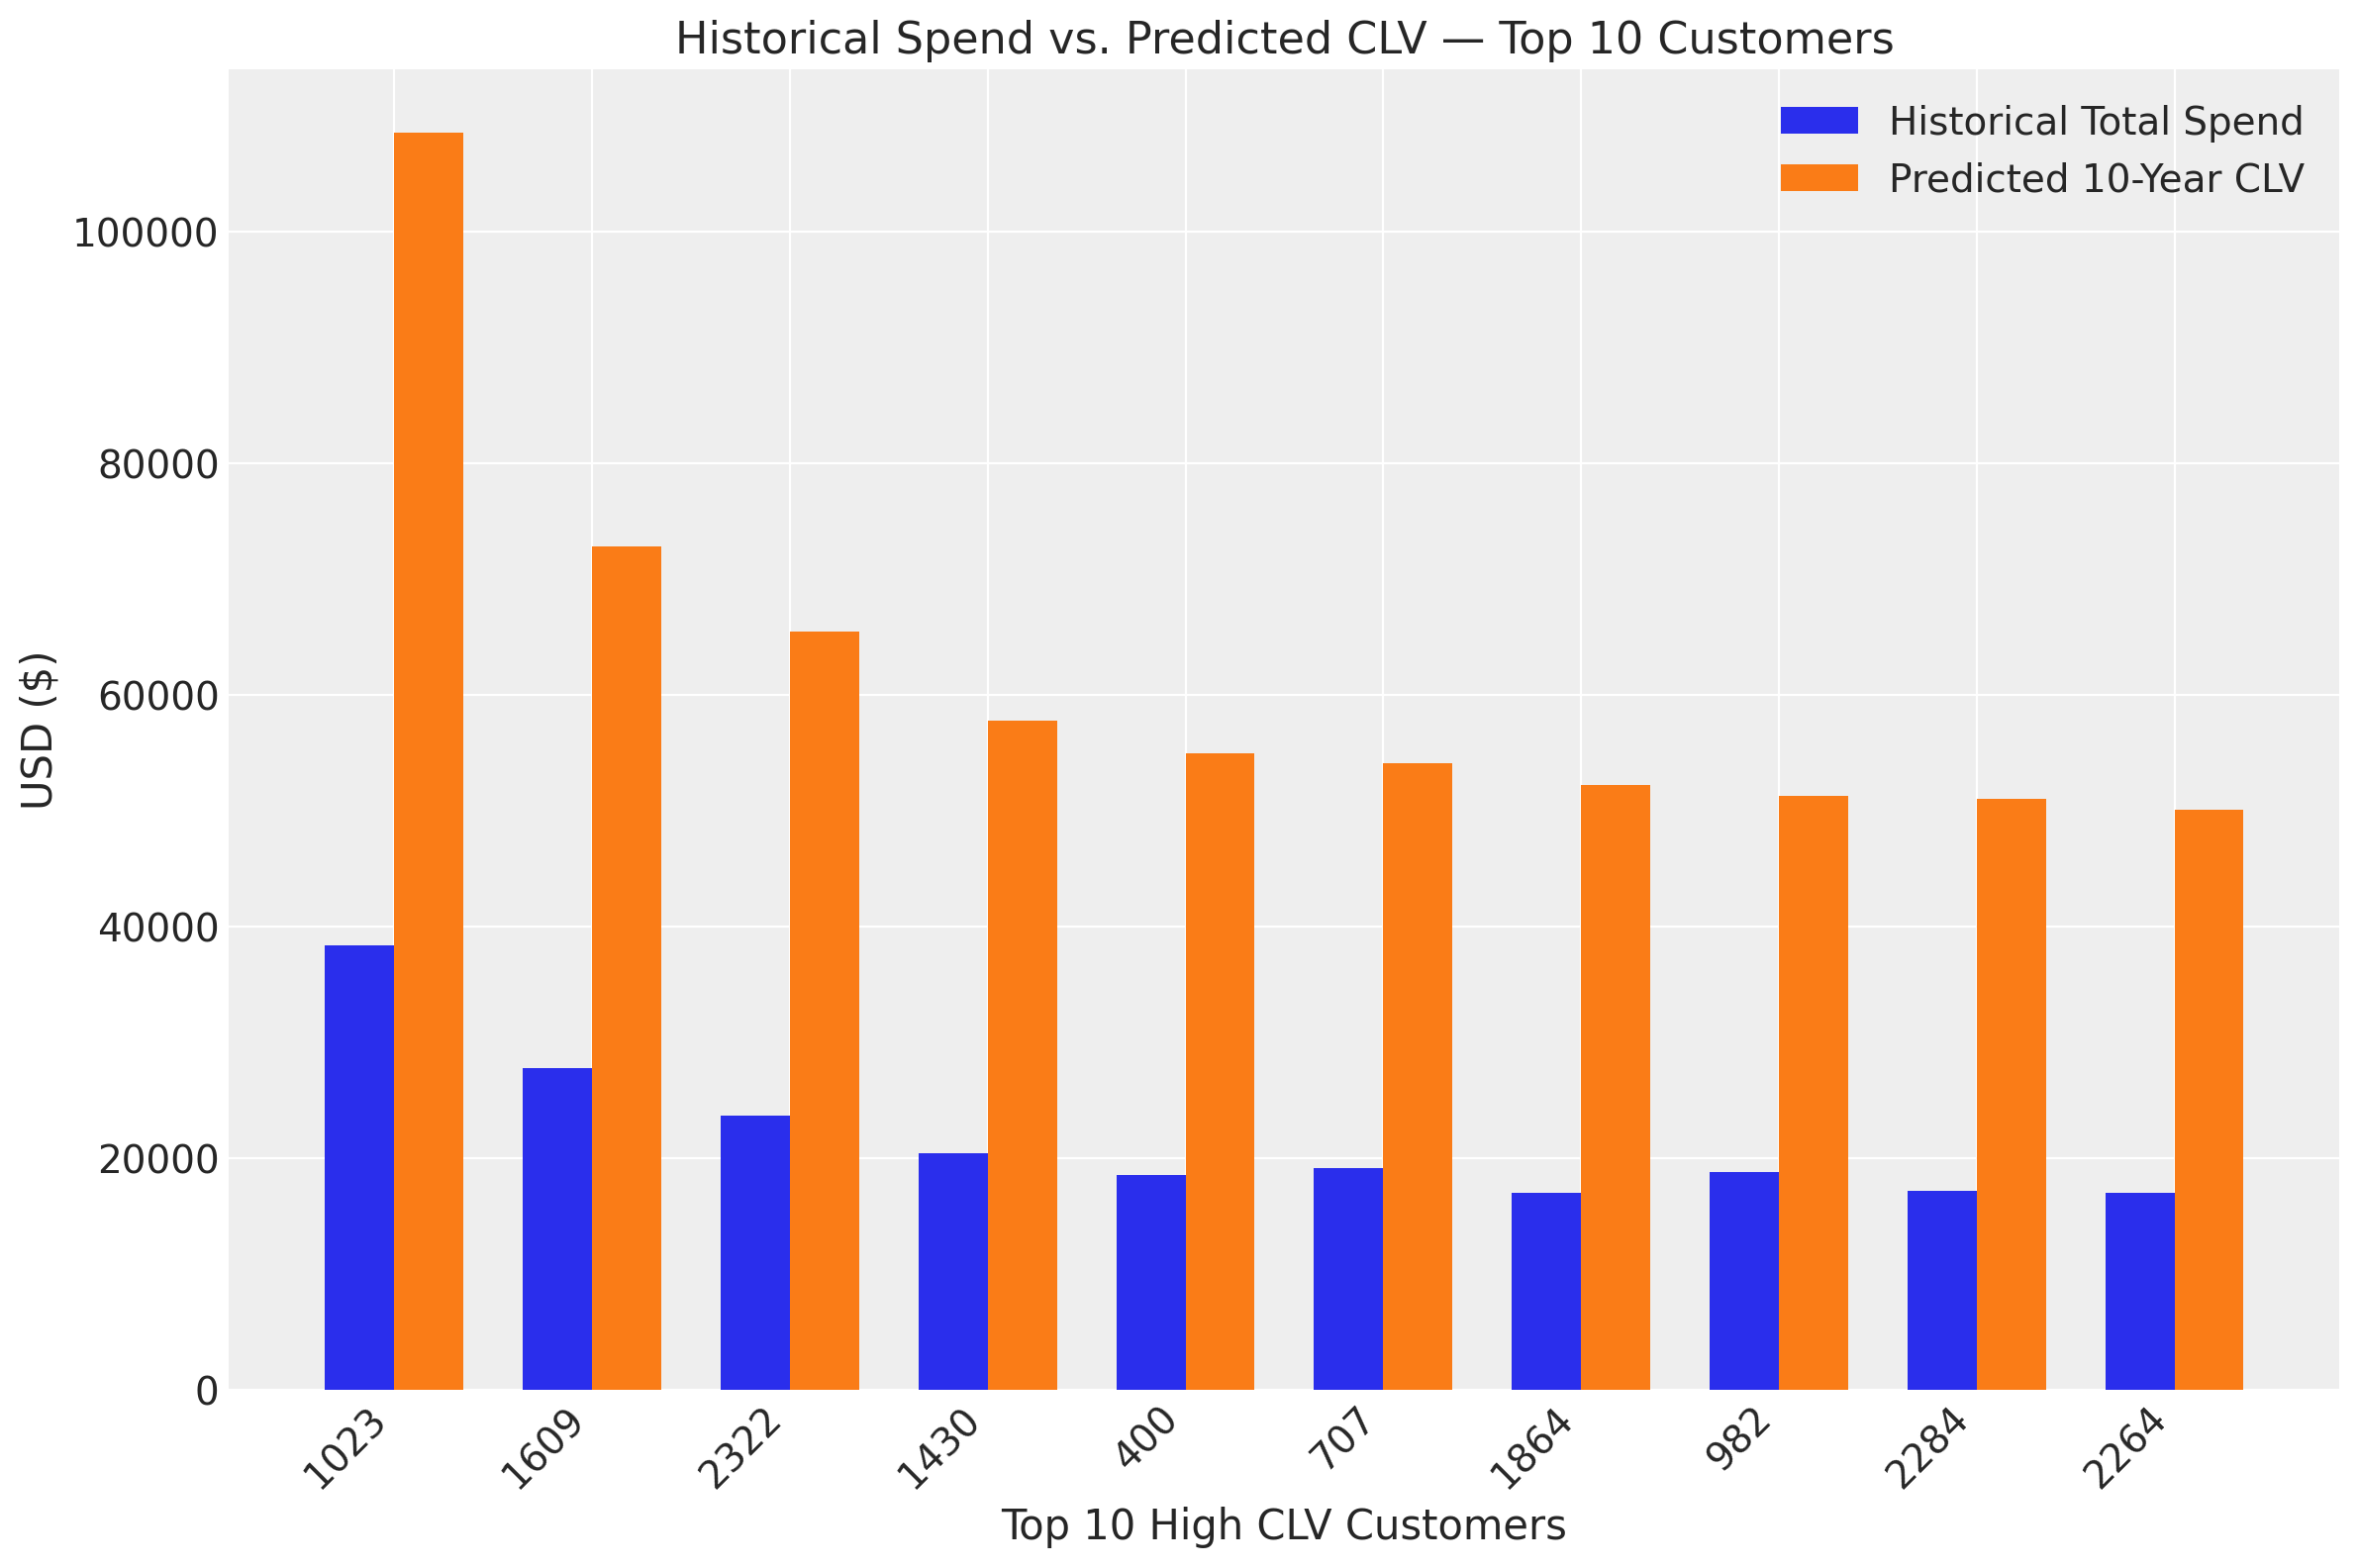

In [55]:
# Add historical total spend for a meaningful comparison with CLV.
# monetary_value is the average per-transaction value; multiply by (frequency+1)
# to get total historical spend.
freq_vals = data_summary.set_index("customer_id").loc[clv_df["customer_id"], "frequency"]
clv_df["total_historical_spend"] = clv_df["monetary_value"] * (freq_vals.values + 1)

# Restrict to status=='ok' so a NaN row doesn't sneak into the headline chart.
top_10_clv = (
    clv_df[clv_df["clv_estimation_status"] == "ok"]
    .sort_values(by='clv_estimate', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.35
index = np.arange(len(top_10_clv))

bar1 = ax.bar(index, top_10_clv['total_historical_spend'], bar_width,
              label='Historical Total Spend')
bar2 = ax.bar(index + bar_width, top_10_clv['clv_estimate'], bar_width,
              label='Predicted 10-Year CLV')

ax.set_xlabel('Top 10 High CLV Customers')
ax.set_ylabel('USD ($)')
ax.set_title('Historical Spend vs. Predicted CLV — Top 10 Customers')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(top_10_clv['customer_id'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

In [56]:
# Join CLV estimates with demographic data to analyze CLV by customer segments.
# Dunnhumby provides demographics for ~801 of 2,500 households.
# We restrict to status=='ok' so the segment averages are not pulled down by
# the small NaN tail.

demographics = load_dunnhumby_demographics()
demographics['household_key'] = demographics['household_key'].astype(str)

clv_with_demo = pd.merge(
    clv_df[clv_df["clv_estimation_status"] == "ok"],
    demographics,
    left_on='customer_id',
    right_on='household_key',
    how='inner',
)

# Analyze CLV by income segment
average_clv_by_income = clv_with_demo.groupby('INCOME_DESC')['clv_estimate'].mean()
customer_count_by_income = clv_with_demo.groupby('INCOME_DESC')['customer_id'].nunique()

income_clv_summary = pd.DataFrame({
    'AverageCLV': average_clv_by_income,
    'CustomerCount': customer_count_by_income,
})

print(f"Households with demographics: {len(clv_with_demo['customer_id'].unique())} / {len(clv_df)}")
income_clv_summary.sort_values('AverageCLV', ascending=False)

Households with demographics: 788 / 2500


,AverageCLV,CustomerCount
INCOME_DESC,,
250K+,30753.947629,11
150-174K,24435.527391,30
175-199K,23012.805975,10
125-149K,20414.569935,36
200-249K,17232.341632,5
75-99K,16790.044748,96
100-124K,16366.201566,33
50-74K,16082.724769,190
Under 15K,14041.433103,59


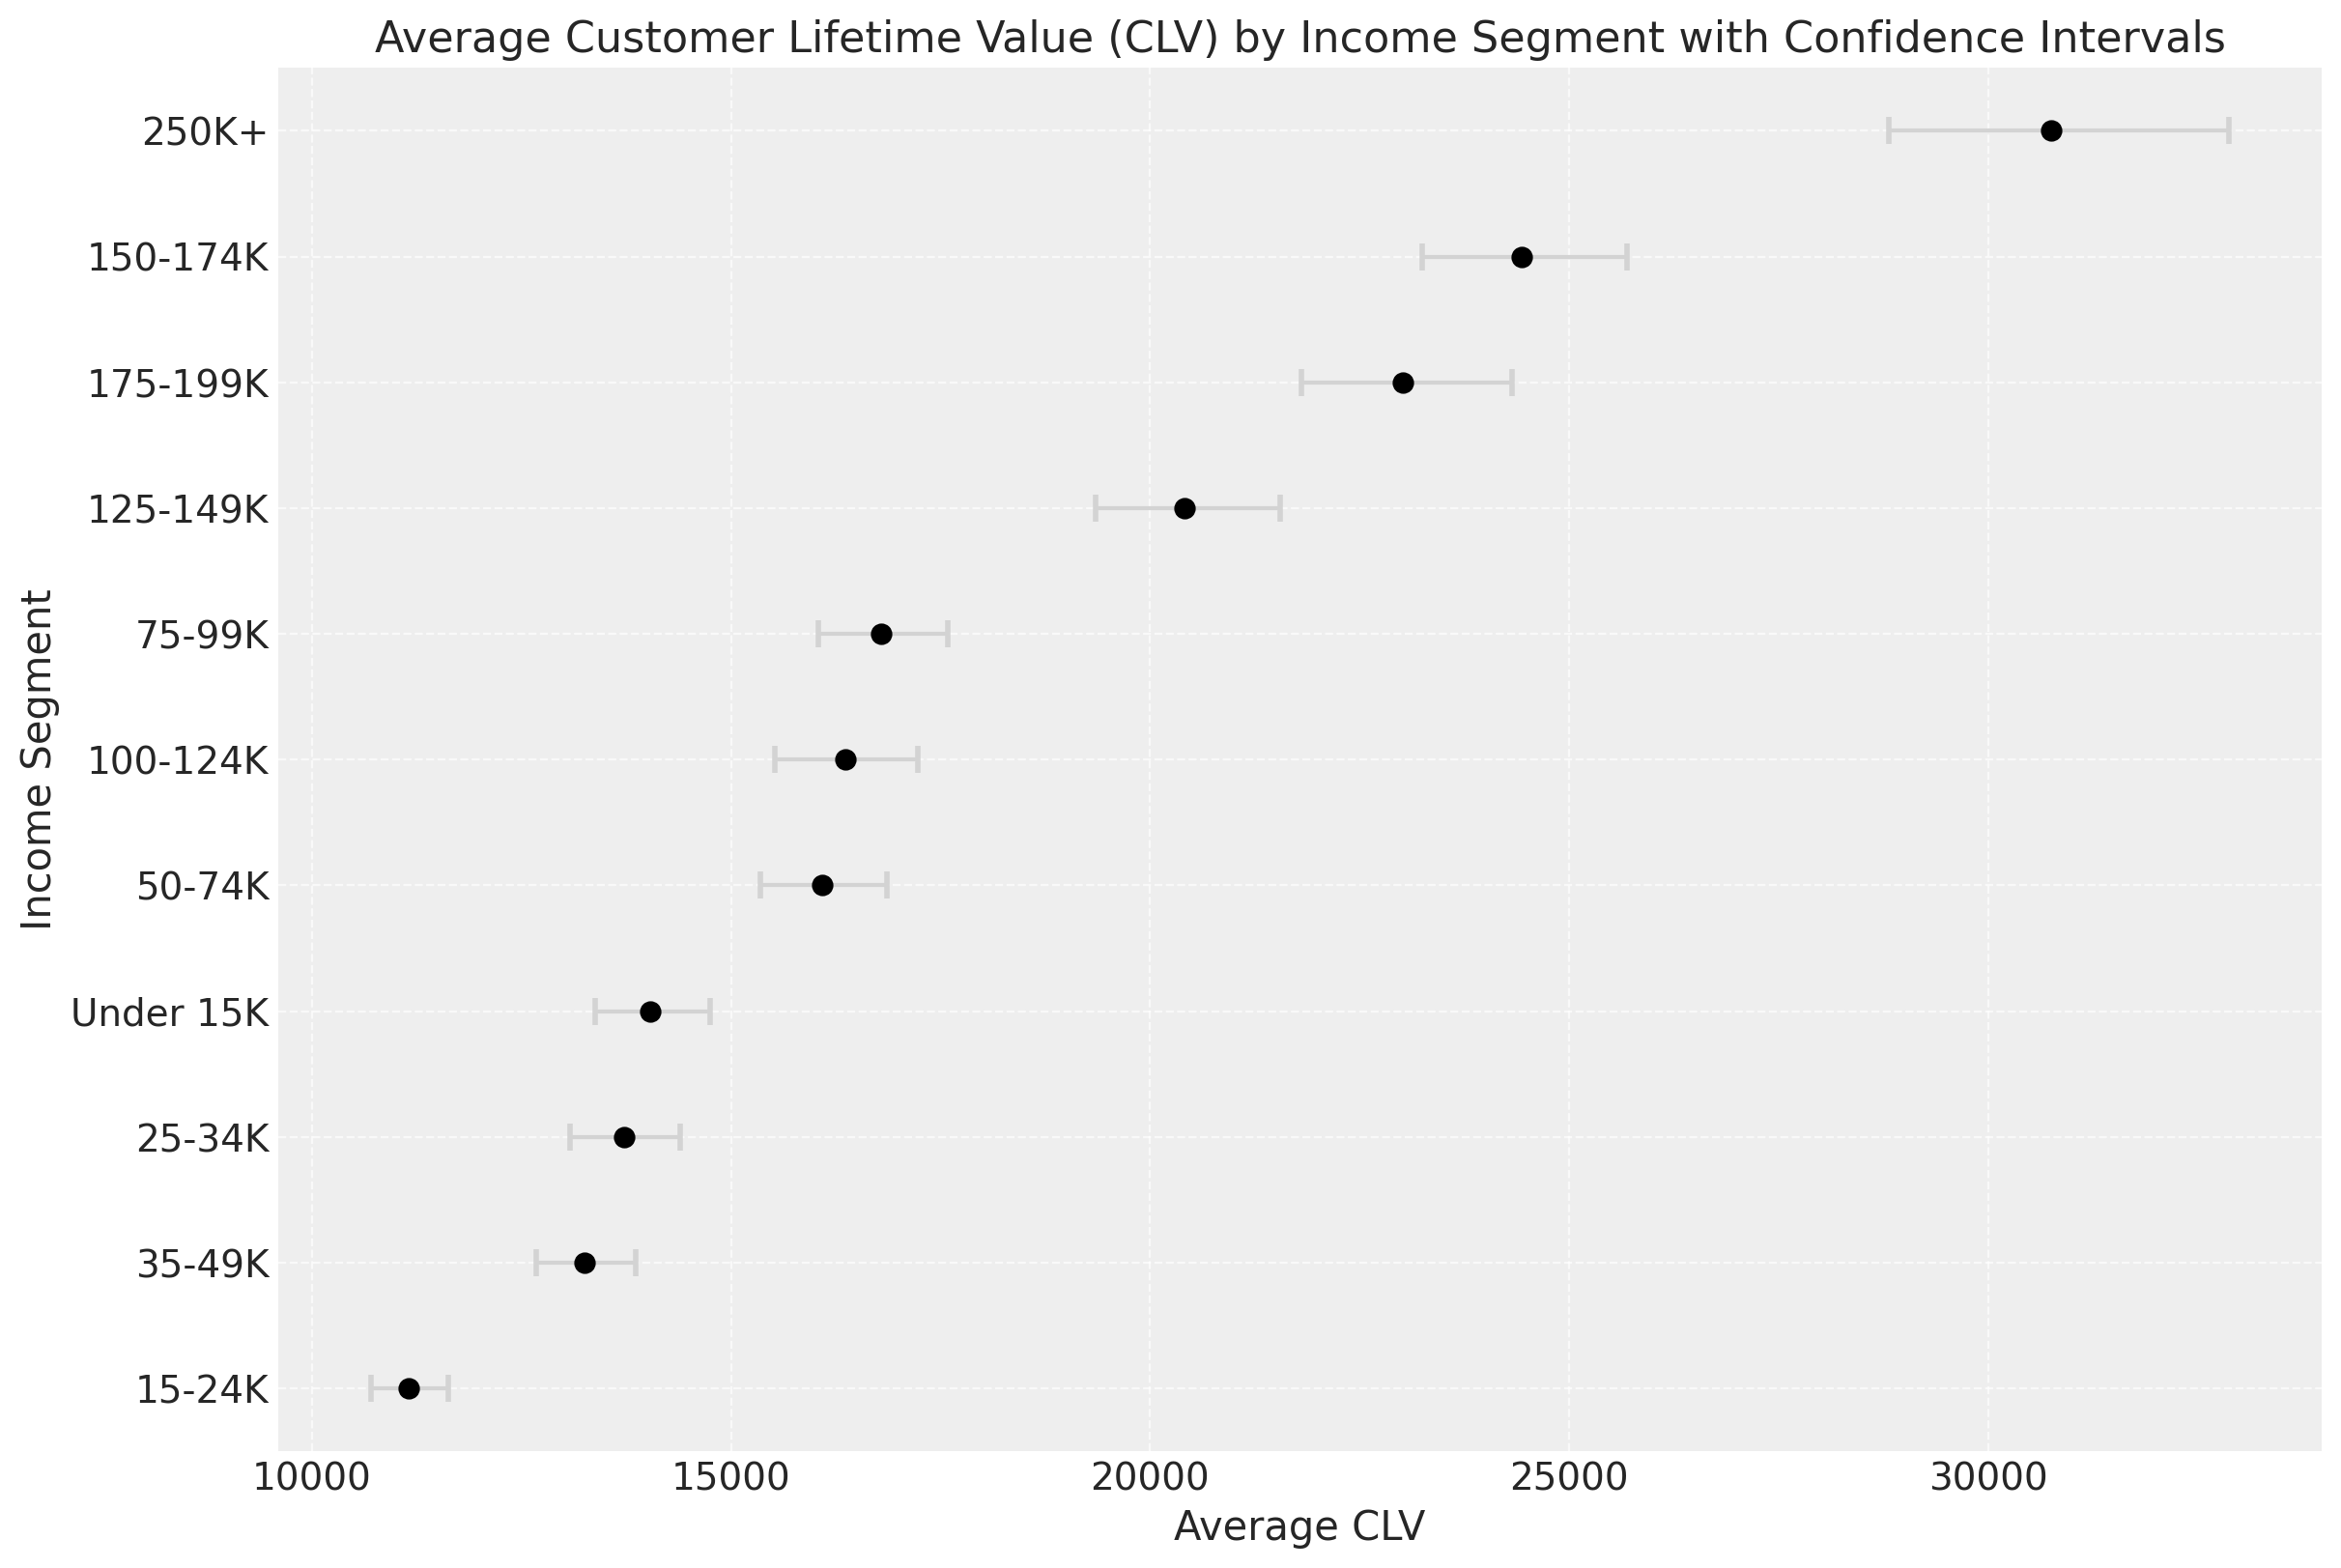

In [57]:
# Calculate the average lower and upper bounds of the CLV estimates by income segment
average_clv_lower = clv_with_demo.groupby('INCOME_DESC')['clv_estimate_hdi_3%'].mean()
average_clv_upper = clv_with_demo.groupby('INCOME_DESC')['clv_estimate_hdi_97%'].mean()

income_clv_summary['AverageCLVLower'] = average_clv_lower
income_clv_summary['AverageCLVUpper'] = average_clv_upper

# Filter segments with at least 10 customers for reliable estimates
filtered = income_clv_summary[income_clv_summary['CustomerCount'] >= 10]
sorted_segments = filtered.sort_values(by='AverageCLV', ascending=False)

# Prepare the data for error bars
lower_error = sorted_segments['AverageCLV'] - sorted_segments['AverageCLVLower']
upper_error = sorted_segments['AverageCLVUpper'] - sorted_segments['AverageCLV']
asymmetric_error = [lower_error, upper_error]

# Create a new figure
plt.figure(figsize=(12, 8))

# Plot average CLV with confidence intervals
plt.errorbar(
    x=sorted_segments['AverageCLV'],
    y=sorted_segments.index.tolist(),
    xerr=asymmetric_error,
    fmt='o', color='black', ecolor='lightgray', capsize=5, markeredgewidth=2,
)

plt.xlabel('Average CLV')
plt.ylabel('Income Segment')
plt.title('Average Customer Lifetime Value (CLV) by Income Segment with Confidence Intervals')
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Putting CLV to Work: Profit, CPA, Segment, Alerts

So far we have a revenue CLV per customer with posterior uncertainty
(we report HDI bounds; we have not run a coverage-calibration study). The
next four cells take that posterior and convert it into the three operating
artifacts the chapter promises: a profit CLV → allowable CPA table for
bidding, a behavioral segment × value cross-tab for CRM treatment design,
and a P(alive) drop watchlist for churn intervention.

In [58]:
# Decision-layer constants. In production these come from finance and the
# media-planning team; treat the values below as illustrative for grocery
# retail and override with your own COGS/discount/horizon table before acting.

GROSS_MARGIN = 0.28              # blended grocery gross margin
TARGET_ACQ_RATIO = 0.33          # spend up to 1/3 of profit CLV to acquire
# `clv.expected_customer_lifetime_value` already discounts to present value
# (monthly 1% over 120 months ≈ 12.7% annual), so no further discounting here.

In [59]:
# Revenue CLV → Profit CLV. We multiply the *full posterior* by the margin
# before reducing, so the HDI on profit CLV is the margin-scaled HDI on
# revenue CLV. If margins vary materially by product mix, replace the scalar
# with a per-customer margin column derived from purchase history.
#
# NaN propagates: rows where the 10y posterior was all-non-finite stay NaN
# in profit_clv too; we filter them out at the aggregation step rather than
# silently zeroing them.

profit_posterior = clv_estimate * GROSS_MARGIN

clv_df["profit_clv_mean"] = profit_posterior.mean(("chain", "draw"), skipna=True).values
profit_hdi = az.hdi(profit_posterior, prob=0.94, skipna=True)
clv_df["profit_clv_hdi_3%"] = profit_hdi.sel(ci_bound="lower").values
clv_df["profit_clv_hdi_97%"] = profit_hdi.sel(ci_bound="upper").values

In [60]:
# Allowable CPA = profit CLV × target acquisition ratio. We report two flavors:
# the mean for planning, and a conservative version using the HDI 3% lower bound
# so under-confident estimates do not over-bid. This is the "bid the lower
# bound" pattern the chapter recommends for value-based bidding.

clv_df["allowable_cpa_mean"] = clv_df["profit_clv_mean"] * TARGET_ACQ_RATIO
clv_df["allowable_cpa_conservative"] = clv_df["profit_clv_hdi_3%"] * TARGET_ACQ_RATIO

# Population summary on the ok-status subset (NaN customers excluded).
ok_clv = clv_df[clv_df["clv_estimation_status"] == "ok"]
print("Profit CLV / Allowable CPA — population summary (status=='ok'):")
print(ok_clv[[
    "profit_clv_mean", "profit_clv_hdi_3%", "profit_clv_hdi_97%",
    "allowable_cpa_mean", "allowable_cpa_conservative",
]].describe(percentiles=[0.5, 0.9, 0.99]).round(0))

Profit CLV / Allowable CPA — population summary (status=='ok'):
       profit_clv_mean  profit_clv_hdi_3%  profit_clv_hdi_97%  \
count           2481.0             2481.0              2481.0   
mean            2520.0             2419.0              2627.0   
std             2568.0             2398.0              2750.0   
min                0.0                0.0                 0.0   
50%             1740.0             1707.0              1774.0   
90%             5760.0             5482.0              6048.0   
99%            12210.0            11326.0             13105.0   
max            30405.0            26589.0             34054.0   

       allowable_cpa_mean  allowable_cpa_conservative  
count              2481.0                      2481.0  
mean                832.0                       798.0  
std                 847.0                       791.0  
min                   0.0                         0.0  
50%                 574.0                       563.0  
90%           

In [61]:
# How much does uncertainty cost? Compare the mean CPA vs the conservative CPA
# for the top-spend customers. A wide gap means you should be cautious bidding
# the mean.

top_cpa = (
    ok_clv.sort_values("allowable_cpa_mean", ascending=False)
    .head(10)[[
        "customer_id",
        "profit_clv_mean", "profit_clv_hdi_3%", "profit_clv_hdi_97%",
        "allowable_cpa_mean", "allowable_cpa_conservative",
    ]]
    .round(0)
)
print("Top-10 customers by allowable CPA (mean vs conservative, status=='ok'):")
top_cpa

Top-10 customers by allowable CPA (mean vs conservative, status=='ok'):


,customer_id,profit_clv_mean,profit_clv_hdi_3%,profit_clv_hdi_97%,allowable_cpa_mean,allowable_cpa_conservative
28,1023,30405.0,26589.0,34054.0,10034.0,8774.0
678,1609,20401.0,18418.0,22561.0,6732.0,6078.0
1471,2322,18327.0,16948.0,19930.0,6048.0,5593.0
480,1430,16189.0,14967.0,17366.0,5342.0,4939.0
1836,400,15394.0,14267.0,16686.0,5080.0,4708.0
2176,707,15160.0,13337.0,16919.0,5003.0,4401.0
961,1864,14631.0,14035.0,15262.0,4828.0,4632.0
2481,982,14354.0,13048.0,15807.0,4737.0,4306.0
1428,2284,14282.0,13225.0,15321.0,4713.0,4364.0
1406,2264,14028.0,12825.0,15406.0,4629.0,4232.0


In [62]:
# Join CLV with the K-Means behavioral segment from the segmentation chapter
# (sec 4.1). The two notebooks share the same Dunnhumby dataset and household
# keys, so this is a straightforward inner join. We carry the status column
# through so the watchlist below can re-filter.

# sec4.1's segmentation chapter writes this file as a cross-section seed.
# Resolved via msbook (cwd-independent), bundled in the repo so this chapter
# can be re-run without first executing sec4.1.
from msbook.paths import chapter_generated

seg_path = chapter_generated(part="4", chapter="sec4.1-segmentation") / "segment_assignments.csv"
segments = pd.read_csv(seg_path)
segments["customer_id"] = segments["household_key"].astype(str)

clv_seg = clv_df.merge(
    segments[["customer_id", "km_segment", "km_action_tier",
              "decile", "decile_action_tier"]],
    on="customer_id",
    how="inner",
)

n_seg_ok = (clv_seg["clv_estimation_status"] == "ok").sum()
print(f"Joined: {len(clv_seg)} / {len(clv_df)} customers have a sec4.1 segment label "
      f"({n_seg_ok} status=='ok').")
clv_seg.head()

Joined: 2500 / 2500 customers have a sec4.1 segment label (2481 status=='ok').


,customer_id,clv_estimate,clv_estimate_hdi_3%,clv_estimate_hdi_97%,clv_3y_mean,clv_5y_mean,clv_estimation_status,horizon_multiplier_10y_over_3y,monetary_value,total_historical_spend,profit_clv_mean,profit_clv_hdi_3%,profit_clv_hdi_97%,allowable_cpa_mean,allowable_cpa_conservative,km_segment,km_action_tier,decile,decile_action_tier
0,1,12768.427215,12549.278429,13015.405809,5745.152494,8459.091579,ok,2.222470,55.214286,4306.714286,3575.159620,3513.797960,3644.313626,1179.802675,1159.553327,0,Growth: upsell,D3,Grow basket or category
1,10,827.613997,817.071249,837.865483,359.241593,535.549987,ok,2.303781,44.947500,224.737500,231.731919,228.779950,234.602335,76.471533,75.497383,2,Behavioral tier 5,D10,Suppress expensive offers
2,100,6640.072110,6600.617804,6678.911521,2917.562676,4331.735938,ok,2.275897,82.451852,2308.651852,1859.220191,1848.172985,1870.095226,613.542663,609.897085,3,Low-cost nurture,D5,Low-cost nurture
3,1000,11963.248314,11567.624189,12387.607263,5473.850358,8010.393001,ok,2.185527,32.721746,4155.661746,3349.709528,3238.934773,3468.530034,1105.404144,1068.848475,1,VIP retention,D3,Grow basket or category
4,1001,11573.293121,11383.002970,11787.135178,5200.532253,7660.854518,ok,2.225406,51.830256,4094.590256,3240.522074,3187.240832,3300.397850,1069.372284,1051.789474,0,Growth: upsell,D3,Grow basket or category


In [63]:
# Operating table: behavioral segment × predicted value. We aggregate over
# status=='ok' rows only — the NaN tail would otherwise drag any segment mean
# toward zero for purely numerical reasons.

ops_segment = (
    clv_seg[clv_seg["clv_estimation_status"] == "ok"]
    .groupby(["km_segment", "km_action_tier"], dropna=False)
    .agg(
        n_customers=("customer_id", "count"),
        mean_profit_clv=("profit_clv_mean", "mean"),
        median_profit_clv=("profit_clv_mean", "median"),
        conservative_profit_clv=("profit_clv_hdi_3%", "mean"),
        mean_allowable_cpa=("allowable_cpa_mean", "mean"),
        conservative_allowable_cpa=("allowable_cpa_conservative", "mean"),
    )
    .round(0)
    .sort_values("mean_profit_clv", ascending=False)
)
print("Operating table — sec4.1 segment × CLV (status=='ok' only):")
ops_segment

Operating table — sec4.1 segment × CLV (status=='ok' only):


,,n_customers,mean_profit_clv,median_profit_clv,conservative_profit_clv,mean_allowable_cpa,conservative_allowable_cpa
km_segment,km_action_tier,,,,,,
1,VIP retention,610,5659.0,4983.0,5368.0,1868.0,1771.0
0,Growth: upsell,567,2553.0,2263.0,2454.0,842.0,810.0
3,Low-cost nurture,539,1537.0,1413.0,1515.0,507.0,500.0
4,Behavioral tier 4,478,934.0,806.0,924.0,308.0,305.0
2,Behavioral tier 5,287,271.0,246.0,267.0,89.0,88.0


In [64]:
# Also profile by decile so the marketing team can size value-based audiences
# directly from the same export.

ops_decile = (
    clv_seg[clv_seg["clv_estimation_status"] == "ok"]
    .groupby("decile", dropna=False)
    .agg(
        n_customers=("customer_id", "count"),
        mean_profit_clv=("profit_clv_mean", "mean"),
        conservative_profit_clv=("profit_clv_hdi_3%", "mean"),
        mean_allowable_cpa=("allowable_cpa_mean", "mean"),
        conservative_allowable_cpa=("allowable_cpa_conservative", "mean"),
    )
    .round(0)
    .sort_index()
)
print("Operating table — decile × CLV (status=='ok' only):")
ops_decile

Operating table — decile × CLV (status=='ok' only):


,n_customers,mean_profit_clv,conservative_profit_clv,mean_allowable_cpa,conservative_allowable_cpa
decile,,,,,
D1,233,8466.0,7941.0,2794.0,2621.0
D10,250,220.0,218.0,73.0,72.0
D2,249,4785.0,4572.0,1579.0,1509.0
D3,249,3526.0,3407.0,1164.0,1124.0
D4,250,2584.0,2508.0,853.0,828.0
D5,250,1996.0,1949.0,659.0,643.0
D6,250,1561.0,1529.0,515.0,504.0
D7,250,1167.0,1150.0,385.0,379.0
D8,250,819.0,811.0,270.0,268.0


### Churn alert: 30-day P(alive) drop

Once a customer has been silent for a while, BG/NBD's posterior probability
they are still active drops. The chapter recommends flagging customers whose
P(alive) is projected to drop more than **30 percentage points over the next
30 days with no purchase**. The signal is the *rate of change*, not the
absolute level — a steady-state low buyer is fine, a sliding ex-loyalist is
not.

We compute P(alive) at T and at T+30 days for every customer in one batch.

In [65]:
# Build two RFM-T frames: "now" (current T) and "+30d" (T + 30, frequency and
# recency unchanged, i.e. no purchase happens). The model returns a posterior
# distribution per customer; we take the posterior mean for the alert
# threshold.

rfmt = data_summary[["customer_id", "frequency", "recency", "T"]].copy()
rfmt["customer_id"] = rfmt["customer_id"].astype(str)

now_input = rfmt.assign(customer_id=rfmt["customer_id"] + "_now")
future_input = rfmt.assign(
    customer_id=rfmt["customer_id"] + "_30d",
    T=rfmt["T"] + 30,
)

p_now = bgm.expected_probability_alive(data=now_input).mean(("chain", "draw")).values
p_30 = bgm.expected_probability_alive(data=future_input).mean(("chain", "draw")).values

alerts = pd.DataFrame({
    "customer_id": rfmt["customer_id"].values,
    "p_alive_now": p_now,
    "p_alive_30d": p_30,
    "p_alive_drop_30d": p_now - p_30,
})

# Merge with profit CLV so the alert list is prioritized by what's at stake.
# `clv_estimation_status` carries through so we can require status=='ok'
# before flagging an alert — a NaN profit CLV cannot be "at risk."
alerts = alerts.merge(
    clv_seg[["customer_id", "profit_clv_mean", "km_segment", "km_action_tier",
             "clv_estimation_status"]],
    on="customer_id",
    how="left",
)
alerts["churn_alert"] = (
    (alerts["p_alive_drop_30d"] >= 0.30)
    & (alerts["clv_estimation_status"] == "ok")
)

n_alert = int(alerts["churn_alert"].sum())
total_at_risk = float(alerts.loc[alerts["churn_alert"], "profit_clv_mean"].sum())
print(f"30-day P(alive) drop alert: {n_alert} of {len(alerts)} customers "
      f"({n_alert / len(alerts):.1%}, status=='ok' only)")
print(f"Profit CLV at risk in the alert list: ${total_at_risk:,.0f}")

30-day P(alive) drop alert: 551 of 2500 customers (22.0%, status=='ok' only)
Profit CLV at risk in the alert list: $2,790,769


In [66]:
# Surface the alert customers ranked by profit CLV — these are the ones a
# save-the-customer campaign should hit first.

watchlist = (
    alerts.query("churn_alert")
    .sort_values("profit_clv_mean", ascending=False)
    .head(15)
    .round(3)
)
print("Top-15 churn-alert customers (sorted by profit CLV at stake):")
watchlist

Top-15 churn-alert customers (sorted by profit CLV at stake):


,customer_id,p_alive_now,p_alive_30d,p_alive_drop_30d,profit_clv_mean,km_segment,km_action_tier,clv_estimation_status,churn_alert
28,1023,0.999,0.000,0.999,30405.070,1,VIP retention,ok,True
678,1609,1.000,0.002,0.997,20400.709,1,VIP retention,ok,True
1471,2322,1.000,0.029,0.971,18326.706,1,VIP retention,ok,True
480,1430,1.000,0.067,0.933,16189.378,1,VIP retention,ok,True
1836,400,1.000,0.038,0.962,15393.683,1,VIP retention,ok,True
2176,707,1.000,0.000,0.999,15159.694,1,VIP retention,ok,True
2481,982,0.999,0.003,0.997,14353.660,1,VIP retention,ok,True
1428,2284,0.999,0.049,0.950,14281.579,1,VIP retention,ok,True
1406,2264,0.999,0.005,0.995,14027.690,1,VIP retention,ok,True
126,1111,0.998,0.009,0.990,13987.194,1,VIP retention,ok,True


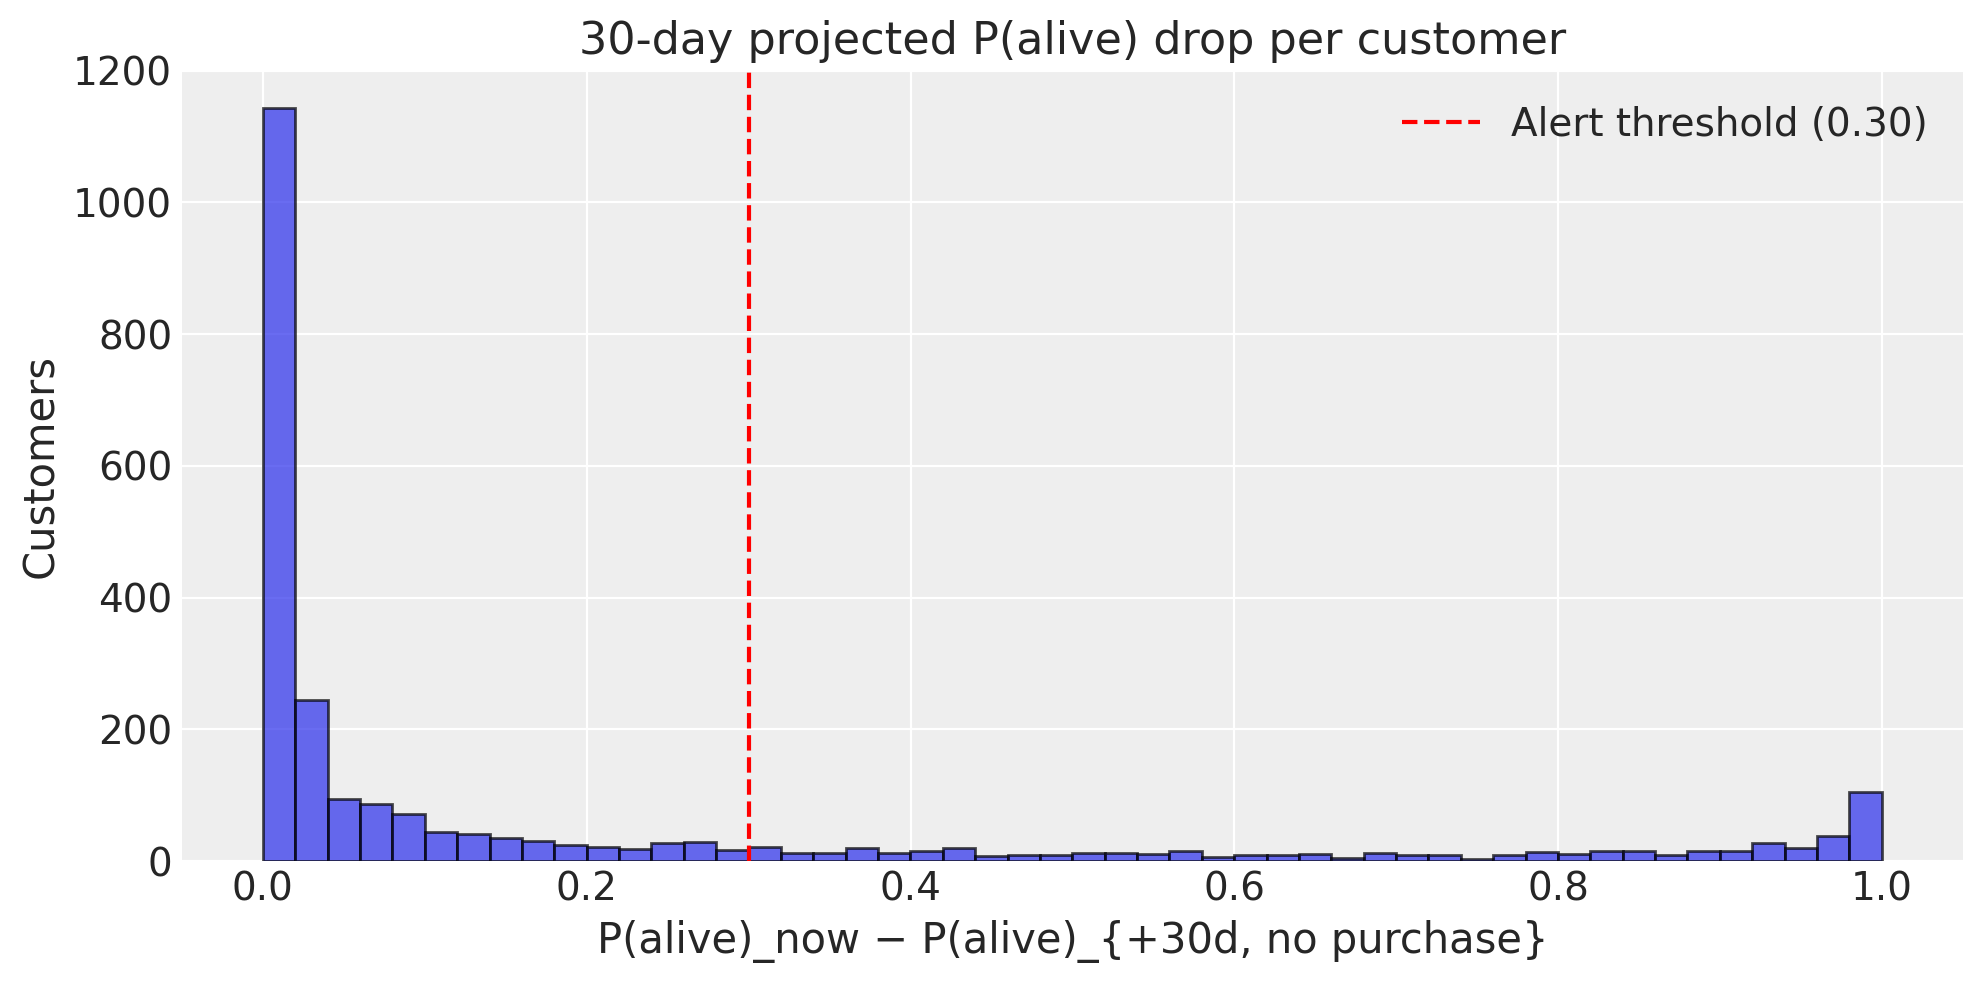

In [67]:
# Visualize the P(alive) drop distribution. Most customers cluster near zero
# drop (they are stable); the right tail above 0.30 is the alert population.

plt.figure(figsize=(10, 5))
plt.hist(alerts["p_alive_drop_30d"], bins=50, edgecolor="k", alpha=0.7)
plt.axvline(0.30, color="red", linestyle="--",
            label="Alert threshold (0.30)")
plt.title("30-day projected P(alive) drop per customer")
plt.xlabel("P(alive)_now − P(alive)_{+30d, no purchase}")
plt.ylabel("Customers")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# Persist the enriched per-customer table. This is the artifact the CRM team
# and the bidding pipeline both consume: one row per household with the
# behavioral segment, posterior-mean CLV, HDI bounds, allowable CPA (mean and
# conservative), and the churn alert flag.

# NOTE: the canonical `clv_estimates_output.csv` is written *after* the
# holdout calibration section below, so the file includes every column we
# discuss in this notebook. (The cell directly below is intentionally a
# preview/sanity-print, not the final export.)

export_cols_preview = [
    "customer_id",
    "km_segment", "km_action_tier", "decile", "decile_action_tier",
    "clv_estimate", "clv_estimate_hdi_3%", "clv_estimate_hdi_97%",
    "clv_3y_mean", "clv_5y_mean", "horizon_multiplier_10y_over_3y",
    "profit_clv_mean", "profit_clv_hdi_3%", "profit_clv_hdi_97%",
    "allowable_cpa_mean", "allowable_cpa_conservative",
    "clv_estimation_status",
]
clv_preview = clv_seg[export_cols_preview].merge(
    alerts[["customer_id", "p_alive_now", "p_alive_30d",
            "p_alive_drop_30d", "churn_alert"]],
    on="customer_id",
    how="left",
)
print(f"Preview row count: {len(clv_preview)}, cols: {clv_preview.shape[1]} "
      f"(canonical CSV written below the holdout section)")
clv_preview.head()

Preview row count: 2500, cols: 21 (canonical CSV written below the holdout section)


,customer_id,km_segment,km_action_tier,decile,decile_action_tier,clv_estimate,clv_estimate_hdi_3%,clv_estimate_hdi_97%,clv_3y_mean,clv_5y_mean,...,profit_clv_mean,profit_clv_hdi_3%,profit_clv_hdi_97%,allowable_cpa_mean,allowable_cpa_conservative,clv_estimation_status,p_alive_now,p_alive_30d,p_alive_drop_30d,churn_alert
0,1,0,Growth: upsell,D3,Grow basket or category,12768.427215,12549.278429,13015.405809,5745.152494,8459.091579,...,3575.159620,3513.797960,3644.313626,1179.802675,1159.553327,ok,0.999201,0.975795,0.023406,False
1,10,2,Behavioral tier 5,D10,Suppress expensive offers,827.613997,817.071249,837.865483,359.241593,535.549987,...,231.731919,228.779950,234.602335,76.471533,75.497383,ok,0.999369,0.999178,0.000190,False
2,100,3,Low-cost nurture,D5,Low-cost nurture,6640.072110,6600.617804,6678.911521,2917.562676,4331.735938,...,1859.220191,1848.172985,1870.095226,613.542663,609.897085,ok,0.998928,0.996559,0.002370,False
3,1000,1,VIP retention,D3,Grow basket or category,11963.248314,11567.624189,12387.607263,5473.850358,8010.393001,...,3349.709528,3238.934773,3468.530034,1105.404144,1068.848475,ok,0.998919,0.780680,0.218239,False
4,1001,0,Growth: upsell,D3,Grow basket or category,11573.293121,11383.002970,11787.135178,5200.532253,7660.854518,...,3240.522074,3187.240832,3300.397850,1069.372284,1051.789474,ok,0.999503,0.986583,0.012920,False


## Holdout Evaluation: Does the Forecast Hold Up?

Convergence diagnostics tell us MCMC ran cleanly, and the segment ×
CLV operating table is monotone — both necessary but neither proves
the model *predicts*. The chapter's Monitoring callout suggests
comparing predicted to actual revenue per cohort at 3, 6, and 12
months as a production monitoring cadence. We illustrate the
**6-month (180-day) case** here as a single anchor because Dunnhumby
only spans 711 days end-to-end: a 12-month holdout would leave just
~11 months of train data and would weaken the BG/NBD fit. In
production with a longer history, run the same procedure at each of
the three horizons and compare the drift ratios.

We use `pymc_marketing.clv.rfm_train_test_split` (in `clv.utils`)
to construct train/test RFM-T tables from the raw transactions, then
refit BG/NBD on the train portion only and compare its predicted
purchases in the holdout window to the actual purchases the customers
made. Refitting on train is the only honest evaluation — reusing the
full-data BG/NBD would leak the test period.

In [69]:
# Build the holdout split using the built-in utility. `train_period_end`
# carves the last HOLDOUT_DAYS off the dataset; `test_period_end` defines
# the upper bound of the comparison window. The returned DataFrame
# carries both train RFM-T and `test_frequency` / `test_monetary_value`
# / `test_T` — exactly what calibration needs.

from pymc_marketing.clv import rfm_train_test_split

HOLDOUT_DAYS = 180
last_day = data["InvoiceDate"].max()
train_end = last_day - pd.Timedelta(days=HOLDOUT_DAYS)

split = rfm_train_test_split(
    transactions=data,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    train_period_end=train_end,
    test_period_end=last_day,
    time_unit="D",
    monetary_value_col="TotalSales",
)
print(f"Train ends   : {train_end.date()}")
print(f"Holdout      : last {HOLDOUT_DAYS} days  ({train_end.date()+pd.Timedelta(days=1)} → {last_day.date()})")
print(f"Total rows in split: {len(split)}")

Train ends   : 2013-06-14
Holdout      : last 180 days  (2013-06-15 → 2013-12-11)
Total rows in split: 2498


In [70]:
# A subset of customers may have *zero* purchases during the train window
# (their first transaction falls in the holdout). BG/NBD cannot say anything
# about a customer it has never seen, so we drop them from the calibration
# sample and report the count.

valid_train = split.query("T > 0").copy()
n_dropped = len(split) - len(valid_train)
print(f"Customers in calibration sample: {len(valid_train)} "
      f"(dropped {n_dropped} with no train-window activity)")

valid_train["customer_id"] = valid_train["customer_id"].astype(str)
valid_train = valid_train.set_index("customer_id", drop=False)

Customers in calibration sample: 2498 (dropped 0 with no train-window activity)


In [71]:
# Refit BG/NBD on the train portion only. We reuse the same v1.0 default priors
# and MCMC settings as the headline fit so the comparison is apples-to-apples;
# only the data changes.

bgm_train = clv.BetaGeoModel()
bgm_train.fit(
    data=valid_train[["customer_id", "frequency", "recency", "T", "monetary_value"]],
    chains=4, draws=1000, tune=1000,
    target_accept=0.95, random_seed=SEED, progressbar=False,
)
n_div_train = int(bgm_train.idata.sample_stats["diverging"].sum().item())
print(f"BG/NBD (train-only) divergences: {n_div_train}")
bgm_train.fit_summary()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, phi_dropout, kappa_dropout, r]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 631 seconds.


Output()

BG/NBD (train-only) divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,9.92,0.31,9.4,10,1622,1855,1.00,0.0078,0.0057
phi_dropout,0.00106,0.00027,0.00071,0.0016,1667,1611,1.00,6.8e-06,6.8e-06
kappa_dropout,95,1.17e+02,24,240,1698,1799,1.00,2.7,14
r,1.394,0.038,1.3,1.5,1611,2026,1.00,0.00094,0.00068
a,0.085,0.08,0.035,0.18,1974,2093,1.00,0.0017,0.0082
b,95,1.17e+02,24,240,1698,1799,1.00,2.7,14


In [72]:
# Predict expected purchases over the holdout window using the *train-only*
# posterior. `future_t` is in the model's time_unit (days), so 180 days
# matches the holdout exactly.

predicted = (
    bgm_train.expected_purchases(
        data=valid_train[["customer_id", "frequency", "recency", "T"]],
        future_t=HOLDOUT_DAYS,
    )
    .mean(("chain", "draw"))
    .values
)

calib = pd.DataFrame({
    "customer_id": valid_train["customer_id"].values,
    "predicted_purchases": predicted,
    "actual_purchases": valid_train["test_frequency"].values,
})

In [73]:
# Aggregate-metric snapshot: MAE / RMSE / Pearson / Spearman on the
# per-customer (predicted, actual) pairs. These are the headline numbers
# a stakeholder will want.

from scipy import stats

mae = float(np.mean(np.abs(calib["predicted_purchases"] - calib["actual_purchases"])))
rmse = float(np.sqrt(np.mean((calib["predicted_purchases"] - calib["actual_purchases"]) ** 2)))
pearson = stats.pearsonr(calib["predicted_purchases"], calib["actual_purchases"])
spearman = stats.spearmanr(calib["predicted_purchases"], calib["actual_purchases"])
agg_actual = calib["actual_purchases"].sum()
agg_pred = calib["predicted_purchases"].sum()

print(f"Holdout = {HOLDOUT_DAYS} days, n = {len(calib)} customers")
print(f"  MAE  (purchases / customer)   : {mae:.2f}")
print(f"  RMSE (purchases / customer)   : {rmse:.2f}")
print(f"  Pearson  r  (pred vs actual)  : {pearson.statistic:.3f}  (p={pearson.pvalue:.2e})")
print(f"  Spearman ρ  (pred vs actual)  : {spearman.statistic:.3f}  (p={spearman.pvalue:.2e})")
print(f"  Aggregate predicted / actual  : {agg_pred / max(agg_actual, 1e-9):.2f}")

Holdout = 180 days, n = 2498 customers
  MAE  (purchases / customer)   : 9.27
  RMSE (purchases / customer)   : 14.22
  Pearson  r  (pred vs actual)  : 0.799  (p=0.00e+00)
  Spearman ρ  (pred vs actual)  : 0.788  (p=0.00e+00)
  Aggregate predicted / actual  : 0.96


In [74]:
# Decile calibration — the canonical CLV evaluation chart. Rank customers
# by predicted purchases, bucket into deciles, compare mean predicted vs
# mean actual per decile. The chapter's monitoring tolerance is ±20%.

calib["pred_decile"] = pd.qcut(
    calib["predicted_purchases"].rank(method="first"),
    q=10, labels=[f"D{i}" for i in range(1, 11)],
)
decile_calib = (
    calib.groupby("pred_decile", observed=True)
    .agg(
        n=("customer_id", "count"),
        mean_predicted=("predicted_purchases", "mean"),
        mean_actual=("actual_purchases", "mean"),
    )
    .round(2)
)
decile_calib["ratio_pred_over_actual"] = (
    decile_calib["mean_predicted"] / decile_calib["mean_actual"].replace(0, np.nan)
).round(2)
decile_calib["within_pm20pct"] = decile_calib["ratio_pred_over_actual"].between(0.80, 1.20)
print("Decile calibration (rank by predicted, compare to actual):")
print(decile_calib)

n_within = int(decile_calib["within_pm20pct"].sum())
print(f"\nDeciles within ±20% tolerance: {n_within} / 10")

Decile calibration (rank by predicted, compare to actual):
               n  mean_predicted  mean_actual  ratio_pred_over_actual  \
pred_decile                                                             
D1           250            1.66         5.95                    0.28   
D2           250            5.40         8.44                    0.64   
D3           250            8.70        10.80                    0.81   
D4           249           12.00        14.02                    0.86   
D5           250           15.84        17.38                    0.91   
D6           250           20.94        22.63                    0.93   
D7           249           26.31        27.29                    0.96   
D8           250           33.01        32.00                    1.03   
D9           250           43.22        45.08                    0.96   
D10          250           73.03        65.56                    1.11   

             within_pm20pct  
pred_decile                  
D1  

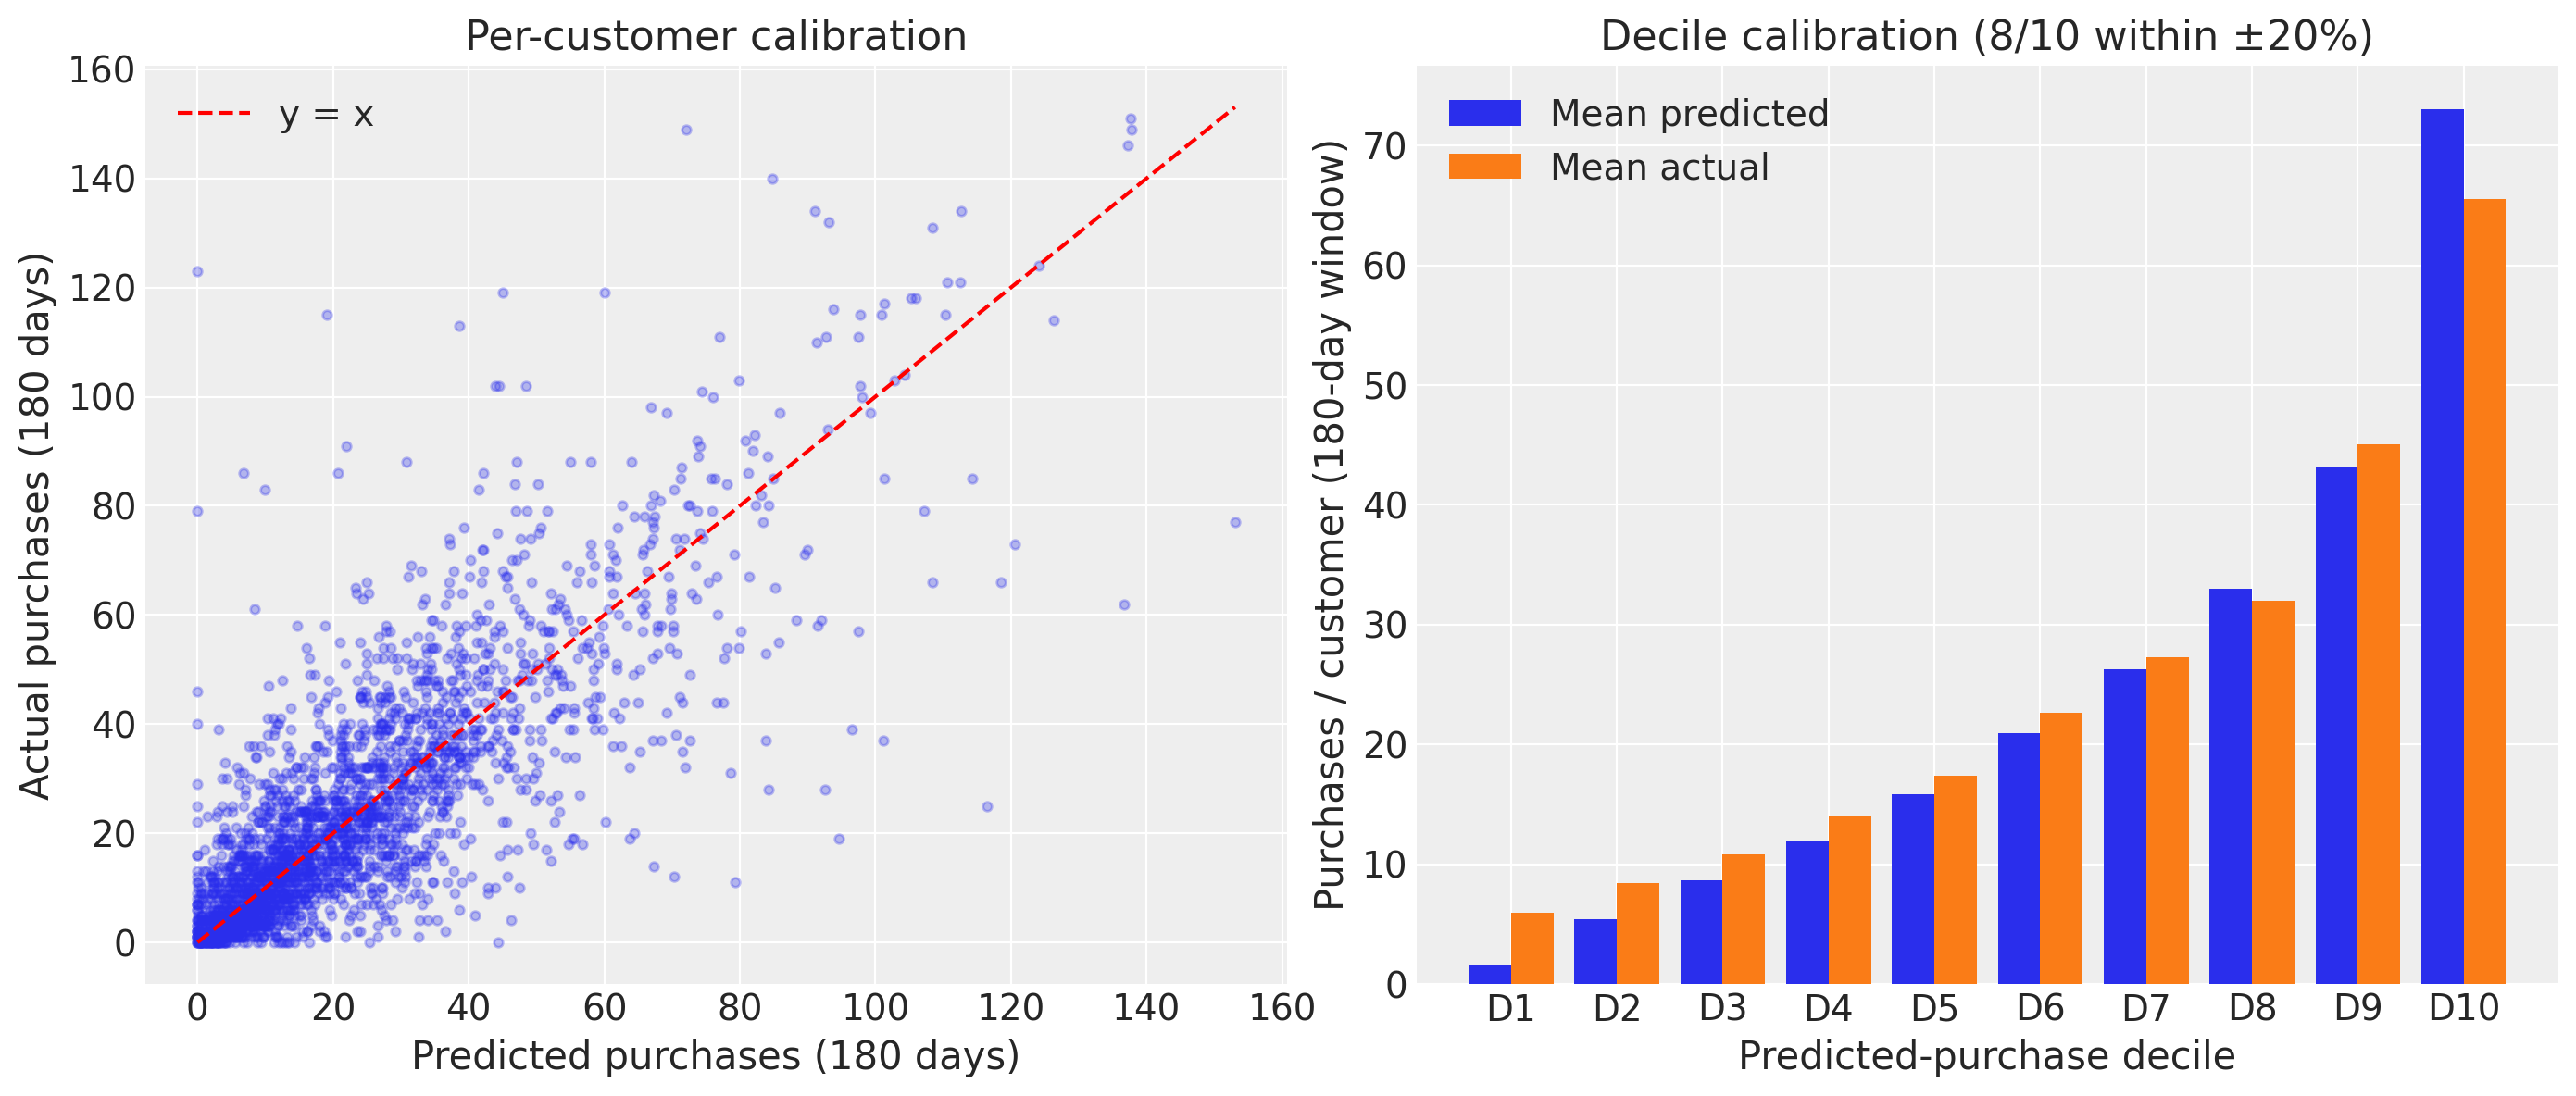

In [75]:
# Visualise the calibration: predicted vs actual scatter with the y=x
# diagonal, plus the decile bar chart.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter
ax1.scatter(calib["predicted_purchases"], calib["actual_purchases"],
            alpha=0.3, s=12)
lim = float(max(calib["predicted_purchases"].max(), calib["actual_purchases"].max()))
ax1.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="y = x")
ax1.set_xlabel("Predicted purchases (180 days)")
ax1.set_ylabel("Actual purchases (180 days)")
ax1.set_title("Per-customer calibration")
ax1.legend()

# Decile bar
idx = np.arange(len(decile_calib))
w = 0.4
ax2.bar(idx - w/2, decile_calib["mean_predicted"], w, label="Mean predicted")
ax2.bar(idx + w/2, decile_calib["mean_actual"], w, label="Mean actual")
ax2.set_xticks(idx)
ax2.set_xticklabels(decile_calib.index.astype(str))
ax2.set_xlabel("Predicted-purchase decile")
ax2.set_ylabel("Purchases / customer (180-day window)")
ax2.set_title(f"Decile calibration ({n_within}/10 within ±20%)")
ax2.legend()
plt.tight_layout()
plt.show()

In [76]:
# Cohort-level revenue calibration. We multiply each customer's predicted
# purchases by their expected average order value (from the full-data
# Gamma-Gamma — AOV is more stationary than purchase frequency, so we accept
# this minor leak rather than refitting GG) and compare to the actual
# holdout revenue.
#
# Gamma-Gamma requires `frequency > 0` (a customer must have at least one
# purchase for AOV to be defined), so we score the GG-eligible subset and
# join back to the calibration table via customer_id. Customers with
# frequency==0 in train get NaN AOV → NaN predicted revenue → excluded from
# the cohort sum below.

gg_eligible = (
    valid_train.query("frequency > 0")
    .reset_index(drop=True)[["customer_id", "monetary_value", "frequency"]]
)
expected_aov = (
    gg.expected_customer_spend(data=gg_eligible)
    .mean(("chain", "draw"))
    .values
)
aov_lookup = pd.DataFrame({
    "customer_id": gg_eligible["customer_id"].astype(str).values,
    "expected_aov": expected_aov,
})

calib = calib.merge(aov_lookup, on="customer_id", how="left")
calib["predicted_revenue"] = calib["predicted_purchases"] * calib["expected_aov"]
calib["actual_revenue"] = (
    valid_train["test_frequency"].fillna(0).values
    * valid_train["test_monetary_value"].fillna(0).values
)

# Restrict the cohort sum to rows where AOV is defined.
cohort_mask = calib["expected_aov"].notna()
cohort_pred = calib.loc[cohort_mask, "predicted_revenue"].sum()
cohort_actual = calib.loc[cohort_mask, "actual_revenue"].sum()
cohort_ratio = cohort_pred / max(cohort_actual, 1e-9)
verdict = (
    "PASS ✅ — inside chapter's ±20% retrain tolerance"
    if 0.80 <= cohort_ratio <= 1.20
    else "DRIFT ⚠ — outside chapter's ±20% retrain tolerance"
)
print(f"Cohort revenue ({int(cohort_mask.sum())} GG-eligible customers, 180d):")
print(f"  predicted ${cohort_pred:,.0f}  /  actual ${cohort_actual:,.0f}")
print(f"  Ratio (predicted / actual): {cohort_ratio:.2f}  → {verdict}")

Cohort revenue (2485 GG-eligible customers, 180d):
  predicted $2,125,555  /  actual $2,311,950
  Ratio (predicted / actual): 0.92  → PASS ✅ — inside chapter's ±20% retrain tolerance


**Caveat.** The Gamma-Gamma model above was fit on the full window;
refitting it on train as well would tighten the test-period purity
of the revenue number, at the cost of another MCMC run. We trade that
precision for runtime here because AOV is far more stationary than
purchase frequency (the actual decision risk is in BG/NBD, which we
*do* refit). In production, refit both.

In [77]:
# Persist the canonical artifact. This is the file the CRM team and the
# bidding pipeline both consume — one row per household, with everything
# the chapter promises and the holdout-calibration evidence backing it.

export_cols_final = [
    "customer_id",
    "km_segment", "km_action_tier", "decile", "decile_action_tier",
    "clv_estimate", "clv_estimate_hdi_3%", "clv_estimate_hdi_97%",
    "clv_3y_mean", "clv_5y_mean", "horizon_multiplier_10y_over_3y",
    "profit_clv_mean", "profit_clv_hdi_3%", "profit_clv_hdi_97%",
    "allowable_cpa_mean", "allowable_cpa_conservative",
    "clv_estimation_status",
]
clv_export = clv_seg[export_cols_final].merge(
    alerts[["customer_id", "p_alive_now", "p_alive_30d",
            "p_alive_drop_30d", "churn_alert"]],
    on="customer_id",
    how="left",
)
from msbook.paths import chapter_artifacts

_clv_csv = chapter_artifacts(part="4", chapter="sec4.2-clv") / "clv_estimates_output.csv"
clv_export.to_csv(_clv_csv, index=False)
print(f"Wrote enriched CLV export → {_clv_csv.name} "
      f"({len(clv_export)} rows, {clv_export.shape[1]} cols)")
clv_export.head()

Wrote enriched CLV export → clv_estimates_output.csv (2500 rows, 21 cols)


,customer_id,km_segment,km_action_tier,decile,decile_action_tier,clv_estimate,clv_estimate_hdi_3%,clv_estimate_hdi_97%,clv_3y_mean,clv_5y_mean,...,profit_clv_mean,profit_clv_hdi_3%,profit_clv_hdi_97%,allowable_cpa_mean,allowable_cpa_conservative,clv_estimation_status,p_alive_now,p_alive_30d,p_alive_drop_30d,churn_alert
0,1,0,Growth: upsell,D3,Grow basket or category,12768.427215,12549.278429,13015.405809,5745.152494,8459.091579,...,3575.159620,3513.797960,3644.313626,1179.802675,1159.553327,ok,0.999201,0.975795,0.023406,False
1,10,2,Behavioral tier 5,D10,Suppress expensive offers,827.613997,817.071249,837.865483,359.241593,535.549987,...,231.731919,228.779950,234.602335,76.471533,75.497383,ok,0.999369,0.999178,0.000190,False
2,100,3,Low-cost nurture,D5,Low-cost nurture,6640.072110,6600.617804,6678.911521,2917.562676,4331.735938,...,1859.220191,1848.172985,1870.095226,613.542663,609.897085,ok,0.998928,0.996559,0.002370,False
3,1000,1,VIP retention,D3,Grow basket or category,11963.248314,11567.624189,12387.607263,5473.850358,8010.393001,...,3349.709528,3238.934773,3468.530034,1105.404144,1068.848475,ok,0.998919,0.780680,0.218239,False
4,1001,0,Growth: upsell,D3,Grow basket or category,11573.293121,11383.002970,11787.135178,5200.532253,7660.854518,...,3240.522074,3187.240832,3300.397850,1069.372284,1051.789474,ok,0.999503,0.986583,0.012920,False


## Key Takeaways from the Notebook

- **Uncertainty is real, not a slogan.** Switching from MAP to NUTS MCMC
  gives every customer a credible interval; the *width* of that interval is
  what makes the "bid the lower bound" rule operable.
- **Don't zero-fill broken posteriors.** Customers whose 10-year DCF
  posterior was entirely non-finite (the highest-frequency tail) are
  flagged `clv_estimation_status="nonfinite_review"` and held out of every
  aggregation. Silently exporting them as \$0-value VIPs would invert the
  operating story.
- **Horizon is a decision.** Revenue CLV at 3y / 5y / 10y is in the export.
  The 10y headline is roughly 2.2× the 3y figure for the bulk of customers
  — read both before sizing acquisition spend against a 10-year promise.
- **Revenue ≠ profit.** Multiplying revenue CLV by gross margin shrinks the
  number you can spend on acquisition by a factor of ~3–4 for grocery. Skip
  this step and your CPA ceiling will systematically overpay.
- **Behavioral segment × CLV is the operating table.** Joining sec4.1's
  K-Means assignment with profit CLV produces "what to do" rather than just
  "who looks valuable." Demographics describe; behavior decides.
- **The 30-day P(alive) drop is the alert worth running.** The rate of
  change beats the absolute level for churn intervention — a steady low
  buyer is not the same as a sliding ex-loyalist.
- **The model predicts, not just describes.** A 180-day holdout shows
  how closely the train-only BG/NBD's predicted purchases track actual
  purchases. The decile-calibration table is the artifact to put in front
  of Finance when they ask "how do you know this number is right?"